*Section 0: Connect to Google Drive*

In [183]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


# Section 1: Setup and Load Dataset

In this section, I import the required Python libraries, upload the Bank Marketing dataset into Google Colab, and load it into a pandas DataFrame. This step confirms that the dataset is accessible and ready for further inspection and preprocessing.

In [184]:
# Import libraries

import os
import io
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from google.colab import files

print("Libraries imported successfully.")

Libraries imported successfully.


## **1.1** Upload the dataset file

Here, I upload the dataset file into the Colab session. I will upload the main CSV file from the Bank Marketing dataset so that it can be loaded and analysed in the following steps.

In [185]:
# Load dataset from Google Drive

import pandas as pd

file_path = "/content/drive/MyDrive/bank-full.csv"

df = pd.read_csv(file_path, sep=";")

print("Dataset loaded successfully.")
print("File path:", file_path)
print("Shape:", df.shape)
display(df.head())

Dataset loaded successfully.
File path: /content/drive/MyDrive/bank-full.csv
Shape: (45211, 17)


,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,58,management,married,tertiary,no,2143,yes,no,unknown,5,may,261,1,-1,0,unknown,no
1,44,technician,single,secondary,no,29,yes,no,unknown,5,may,151,1,-1,0,unknown,no
2,33,entrepreneur,married,secondary,no,2,yes,yes,unknown,5,may,76,1,-1,0,unknown,no
3,47,blue-collar,married,unknown,no,1506,yes,no,unknown,5,may,92,1,-1,0,unknown,no
4,33,unknown,single,unknown,no,1,no,no,unknown,5,may,198,1,-1,0,unknown,no


## **1.2** Confirm target column

This cell verifies that the target variable is present and checks the class distribution for the binary classification task.

In [186]:
# Confirming target column

print("Columns:")
print(df.columns.tolist())

print("\nTarget value counts:")
print(df["y"].value_counts())

print("\nTarget proportions:")
print(df["y"].value_counts(normalize=True))

Columns:
['age', 'job', 'marital', 'education', 'default', 'balance', 'housing', 'loan', 'contact', 'day', 'month', 'duration', 'campaign', 'pdays', 'previous', 'poutcome', 'y']

Target value counts:
y
no     39922
yes     5289
Name: count, dtype: int64

Target proportions:
y
no     0.883015
yes    0.116985
Name: proportion, dtype: float64


# Section 2: Initial Data Inspection

In this section, I perform an initial inspection of the Bank Marketing dataset. The aim is to understand the dataset size, feature types, numerical summaries, and categorical variables before carrying out any cleaning, preprocessing, or exploratory data analysis.

In [187]:
# Check overall structure

print("Dataset shape:", df.shape)
print("\nData types:")
print(df.dtypes)

print("\nDetailed info:")
df.info()

Dataset shape: (45211, 17)

Data types:
age           int64
job          object
marital      object
education    object
default      object
balance       int64
housing      object
loan         object
contact      object
day           int64
month        object
duration      int64
campaign      int64
pdays         int64
previous      int64
poutcome     object
y            object
dtype: object

Detailed info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45211 entries, 0 to 45210
Data columns (total 17 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   age        45211 non-null  int64 
 1   job        45211 non-null  object
 2   marital    45211 non-null  object
 3   education  45211 non-null  object
 4   default    45211 non-null  object
 5   balance    45211 non-null  int64 
 6   housing    45211 non-null  object
 7   loan       45211 non-null  object
 8   contact    45211 non-null  object
 9   day        45211 non-null  int64 
 10  month   

## **2.1** Numerical feature summary

This cell provides descriptive statistics for the numerical features in the dataset. It helps identify the range, spread, and central tendency of the continuous and integer-based variables.

In [188]:
# Summary statistics for numerical columns

print("Numerical summary statistics:")
display(df.describe())

Numerical summary statistics:


,age,balance,day,duration,campaign,pdays,previous
count,45211.000000,45211.000000,45211.000000,45211.000000,45211.000000,45211.000000,45211.000000
mean,40.936210,1362.272058,15.806419,258.163080,2.763841,40.197828,0.580323
std,10.618762,3044.765829,8.322476,257.527812,3.098021,100.128746,2.303441
min,18.000000,-8019.000000,1.000000,0.000000,1.000000,-1.000000,0.000000
25%,33.000000,72.000000,8.000000,103.000000,1.000000,-1.000000,0.000000
50%,39.000000,448.000000,16.000000,180.000000,2.000000,-1.000000,0.000000
75%,48.000000,1428.000000,21.000000,319.000000,3.000000,-1.000000,0.000000
max,95.000000,102127.000000,31.000000,4918.000000,63.000000,871.000000,275.000000


## **2.2** Separate numerical and categorical features

This cell identifies which variables are numerical and which are categorical. This is important because both groups will require different preprocessing techniques later.

In [189]:
# Identify numerical and categorical columns

numerical_cols = df.select_dtypes(include=["int64", "float64"]).columns.tolist()
categorical_cols = df.select_dtypes(include=["object"]).columns.tolist()

print("Numerical columns:")
print(numerical_cols)

print("\nCategorical columns:")
print(categorical_cols)

print("\nNumber of numerical columns:", len(numerical_cols))
print("Number of categorical columns:", len(categorical_cols))

Numerical columns:
['age', 'balance', 'day', 'duration', 'campaign', 'pdays', 'previous']

Categorical columns:
['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'poutcome', 'y']

Number of numerical columns: 7
Number of categorical columns: 10


## **2.3** Inspect unique values in categorical features

This cell checks the unique values present in each categorical variable. This helps identify important categories, possible inconsistencies, and special values such as 'unknown' that need attention.

In [190]:
# Unique values in categorical columns

for col in categorical_cols:
    print(f"\nColumn: {col}")
    print("Number of unique values:", df[col].nunique())
    print("Unique values:", sorted(df[col].unique()))


Column: job
Number of unique values: 12
Unique values: ['admin.', 'blue-collar', 'entrepreneur', 'housemaid', 'management', 'retired', 'self-employed', 'services', 'student', 'technician', 'unemployed', 'unknown']

Column: marital
Number of unique values: 3
Unique values: ['divorced', 'married', 'single']

Column: education
Number of unique values: 4
Unique values: ['primary', 'secondary', 'tertiary', 'unknown']

Column: default
Number of unique values: 2
Unique values: ['no', 'yes']

Column: housing
Number of unique values: 2
Unique values: ['no', 'yes']

Column: loan
Number of unique values: 2
Unique values: ['no', 'yes']

Column: contact
Number of unique values: 3
Unique values: ['cellular', 'telephone', 'unknown']

Column: month
Number of unique values: 12
Unique values: ['apr', 'aug', 'dec', 'feb', 'jan', 'jul', 'jun', 'mar', 'may', 'nov', 'oct', 'sep']

Column: poutcome
Number of unique values: 4
Unique values: ['failure', 'other', 'success', 'unknown']

Column: y
Number of uniq

## **2.4** Check class balance

This cell reconfirms the class distribution of the target variable. This is useful because class imbalance will influence model training and evaluation choices later in the project.

In [191]:
# Target distribution summary

target_counts = df["y"].value_counts()
target_props = df["y"].value_counts(normalize=True) * 100

print("Target counts:")
print(target_counts)

print("\nTarget percentages:")
print(target_props.round(2))

Target counts:
y
no     39922
yes     5289
Name: count, dtype: int64

Target percentages:
y
no     88.3
yes    11.7
Name: proportion, dtype: float64


# Section 3: Data Quality Checks

In this section, I evaluate the quality of the Bank Marketing dataset before carrying out exploratory data analysis and preprocessing. The checks include missing values, duplicate rows, unknown categories in categorical variables, and special coded values that may affect model training.

In [192]:
# Checking for missing values

missing_counts = df.isnull().sum()
missing_percent = (df.isnull().sum() / len(df)) * 100

missing_df = pd.DataFrame({
    "Missing Count": missing_counts,
    "Missing Percentage": missing_percent
})

print("Missing values by column:")
display(missing_df)

Missing values by column:


,Missing Count,Missing Percentage
age,0,0.0
job,0,0.0
marital,0,0.0
education,0,0.0
default,0,0.0
balance,0,0.0
housing,0,0.0
loan,0,0.0
contact,0,0.0
day,0,0.0


## **3.1** Check for duplicate records

This cell identifies whether the dataset contains duplicate rows. Duplicate observations can bias model training and evaluation, so they need to be detected before further processing.

In [193]:
# Check for duplicate rows

duplicate_count = df.duplicated().sum()
duplicate_percent = (duplicate_count / len(df)) * 100

print("Number of duplicate rows:", duplicate_count)
print("Percentage of duplicate rows:", round(duplicate_percent, 4), "%")

Number of duplicate rows: 0
Percentage of duplicate rows: 0.0 %


## **3.2** Identifying unknown categories

This cell checks how often the category 'unknown' appears in categorical features. Although these are not technically missing values, they still represent incomplete or uncertain information and may influence preprocessing decisions.

In [194]:
# Counting the 'unknown' values in categorical columns

unknown_summary = {}

for col in categorical_cols:
    unknown_count = (df[col] == "unknown").sum()
    unknown_percent = (unknown_count / len(df)) * 100
    unknown_summary[col] = {
        "Unknown Count": unknown_count,
        "Unknown Percentage": round(unknown_percent, 2)
    }

unknown_df = pd.DataFrame(unknown_summary).T
print("Summary of 'unknown' values:")
display(unknown_df)

Summary of 'unknown' values:


,Unknown Count,Unknown Percentage
job,288.0,0.64
marital,0.0,0.00
education,1857.0,4.11
default,0.0,0.00
housing,0.0,0.00
loan,0.0,0.00
contact,13020.0,28.80
month,0.0,0.00
poutcome,36959.0,81.75
y,0.0,0.00


## **3.3** Inspecting special values in pdays

This cell investigates the variable 'pdays', where the value -1 commonly indicates that the client was not previously contacted. This is important because it is a coded category rather than a standard numerical measurement.

In [195]:
# Investigating special values in pdays

pdays_neg1_count = (df["pdays"] == -1).sum()
pdays_neg1_percent = (pdays_neg1_count / len(df)) * 100

print("Number of rows where pdays = -1:", pdays_neg1_count)
print("Percentage of rows where pdays = -1:", round(pdays_neg1_percent, 2), "%")

print("\nTop pdays value counts:")
print(df["pdays"].value_counts().head(10))

Number of rows where pdays = -1: 36954
Percentage of rows where pdays = -1: 81.74 %

Top pdays value counts:
pdays
-1      36954
 182      167
 92       147
 183      126
 91       126
 181      117
 370       99
 184       85
 364       77
 95        74
Name: count, dtype: int64


## 3.4 Inspect suspicious numerical ranges

This cell checks the minimum and maximum values of numerical variables to identify unusually large ranges, negative values, and possible outliers that may need to be handled during preprocessing.

In [196]:
#Checking numerical ranges

range_summary = pd.DataFrame({
    "Minimum": df[numerical_cols].min(),
    "Maximum": df[numerical_cols].max(),
    "Mean": df[numerical_cols].mean(),
    "Median": df[numerical_cols].median()
})

print("Numerical range summary:")
display(range_summary)

Numerical range summary:


,Minimum,Maximum,Mean,Median
age,18,95,40.936210,39.0
balance,-8019,102127,1362.272058,448.0
day,1,31,15.806419,16.0
duration,0,4918,258.163080,180.0
campaign,1,63,2.763841,2.0
pdays,-1,871,40.197828,-1.0
previous,0,275,0.580323,0.0


# Section 4: Exploratory Data Analysis (Part 1 - Target and Categorical Features)

In this section, I begin exploratory data analysis by examining the target variable and the main categorical predictors. The goal is to understand class imbalance and identify whether certain customer categories are associated with higher or lower subscription rates.

In [197]:
# Basic plotting setup

import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (8, 5)

## **4.1** Target class distribution

This cell visualises the distribution of the target variable to confirm the class imbalance between customers who subscribed and those who did not subscribe to the term deposit.

Target counts:
y
no     39922
yes     5289
Name: count, dtype: int64

Target percentages:
y
no     88.3
yes    11.7
Name: proportion, dtype: float64


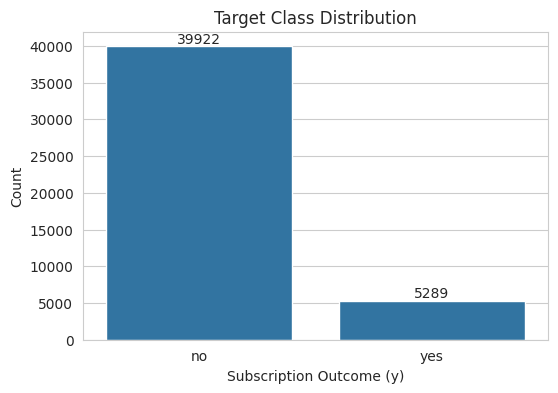

In [144]:
# Target distribution plot

target_counts = df["y"].value_counts()
target_percent = df["y"].value_counts(normalize=True) * 100

print("Target counts:")
print(target_counts)

print("\nTarget percentages:")
print(target_percent.round(2))

plt.figure(figsize=(6, 4))
ax = sns.countplot(data=df, x="y")
plt.title("Target Class Distribution")
plt.xlabel("Subscription Outcome (y)")
plt.ylabel("Count")

for p in ax.patches:
    ax.annotate(f"{int(p.get_height())}",
                (p.get_x() + p.get_width() / 2, p.get_height()),
                ha="center", va="bottom")

plt.show()

## **4.2** Subscription rate by job

This cell examines how the subscription rate varies across job categories. It helps identify whether occupation appears to influence the likelihood of subscribing to the term deposit.

Subscription rate by job (%):


,Subscription Rate (%)
job,
student,28.678038
retired,22.791519
unemployed,15.502686
management,13.755551
admin.,12.202669
self-employed,11.842939
unknown,11.805556
technician,11.056996
services,8.883004


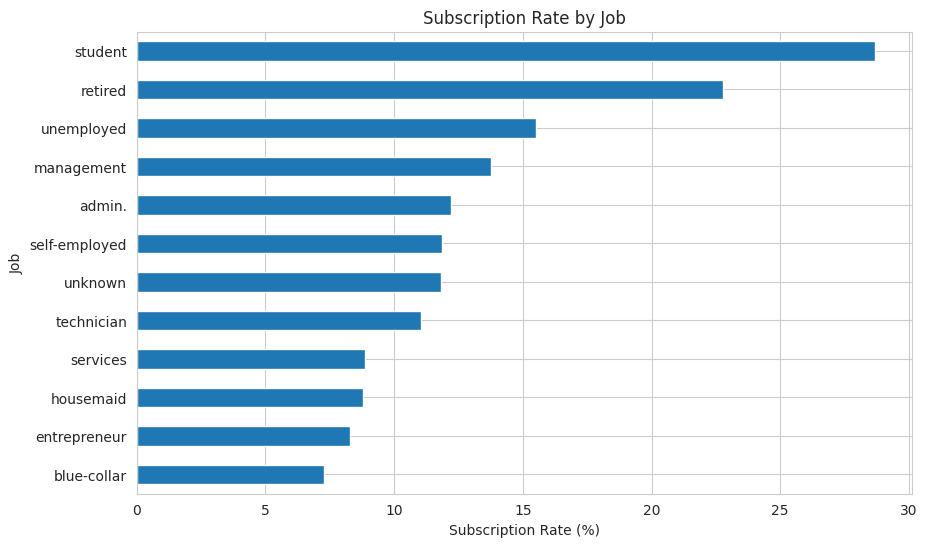

In [145]:
# Subscription rate by job

job_rate = (
    df.groupby("job")["y"]
    .apply(lambda x: (x == "yes").mean())
    .sort_values(ascending=False)
    * 100
)

print("Subscription rate by job (%):")
display(job_rate.to_frame(name="Subscription Rate (%)"))

plt.figure(figsize=(10, 6))
job_rate.plot(kind="barh")
plt.title("Subscription Rate by Job")
plt.xlabel("Subscription Rate (%)")
plt.ylabel("Job")
plt.gca().invert_yaxis()  # highest rate at top
plt.show()

## **4.3** Subscription rate by education

This cell compares subscription rates across education levels. It helps reveal whether educational background is associated with different customer response patterns.


Subscription rate by education (%):


,Subscription Rate (%)
education,
tertiary,15.006390
unknown,13.570275
secondary,10.559435
primary,8.626478


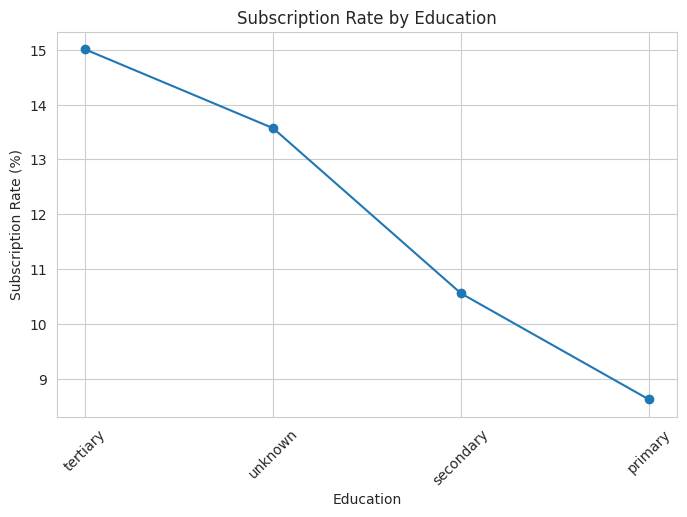

In [146]:
# Subscription rate by education

education_rate = (
    df.groupby("education")["y"]
    .apply(lambda x: (x == "yes").mean())
    .sort_values(ascending=False)
    * 100
)

print("Subscription rate by education (%):")
display(education_rate.to_frame(name="Subscription Rate (%)"))

plt.figure(figsize=(8, 5))
plt.plot(education_rate.index, education_rate.values, marker='o', linestyle='-')
plt.title("Subscription Rate by Education")
plt.xlabel("Education")
plt.ylabel("Subscription Rate (%)")
plt.xticks(rotation=45)
plt.show()

## **4.4** Subscription rate by contact type

This cell investigates whether the communication contact type is associated with customer subscription behaviour. Since the variable contains many 'unknown' values, it is important to understand how this category behaves.

Subscription rate by contact type (%):


,Subscription Rate (%)
contact,
cellular,14.918900
telephone,13.420509
unknown,4.070661


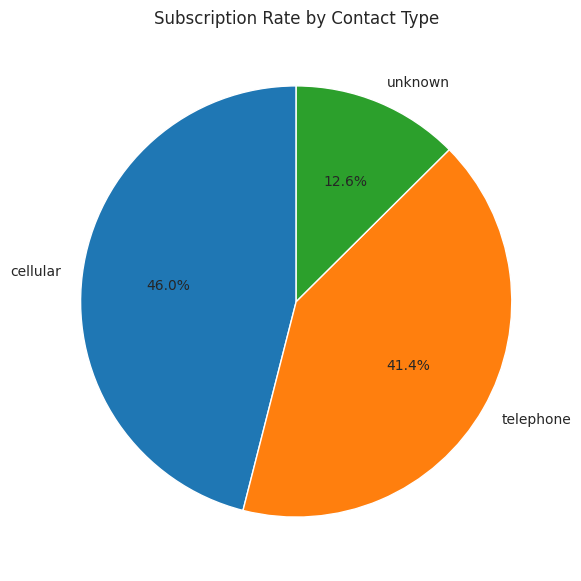

In [147]:
# Subscription rate by contact type

contact_rate = (
    df.groupby("contact")["y"]
    .apply(lambda x: (x == "yes").mean())
    .sort_values(ascending=False)
    * 100
)

print("Subscription rate by contact type (%):")
display(contact_rate.to_frame(name="Subscription Rate (%)"))

plt.figure(figsize=(7, 7))
plt.pie(contact_rate.values, labels=contact_rate.index, autopct='%1.1f%%', startangle=90)
plt.title("Subscription Rate by Contact Type")
plt.show()

## **4.5** Subscription rate by previous campaign outcome

This cell analyses the relationship between the outcome of the previous marketing campaign and the current subscription rate. This variable may be highly informative, even though many observations contain the category 'unknown'.

Subscription rate by previous campaign outcome (%):


,Subscription Rate (%)
poutcome,
success,64.725347
other,16.684783
failure,12.609671
unknown,9.161503


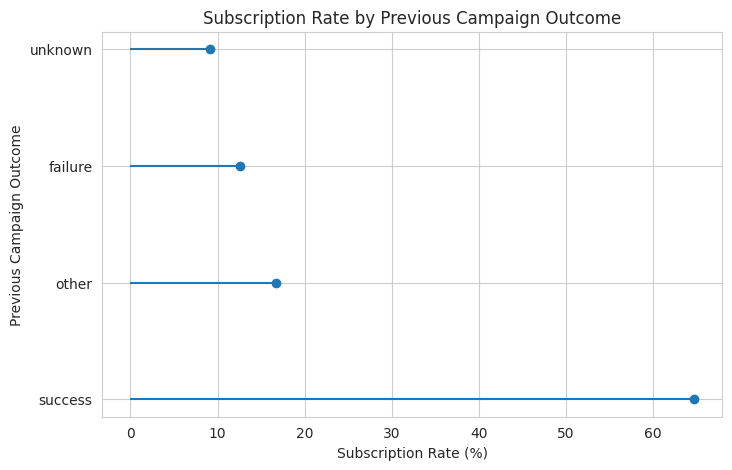

In [148]:
# Subscription rate by previous campaign outcome

poutcome_rate = (
    df.groupby("poutcome")["y"]
    .apply(lambda x: (x == "yes").mean())
    .sort_values(ascending=False)
    * 100
)

print("Subscription rate by previous campaign outcome (%):")
display(poutcome_rate.to_frame(name="Subscription Rate (%)"))

plt.figure(figsize=(8, 5))
plt.hlines(y=poutcome_rate.index, xmin=0, xmax=poutcome_rate.values)
plt.plot(poutcome_rate.values, poutcome_rate.index, "o")
plt.title("Subscription Rate by Previous Campaign Outcome")
plt.xlabel("Subscription Rate (%)")
plt.ylabel("Previous Campaign Outcome")
plt.show()

In [149]:
# Compact insight summary

print("Top 3 job categories by subscription rate:")
print(job_rate.head(3).round(2))

print("\nEducation categories by subscription rate:")
print(education_rate.round(2))

print("\nContact types by subscription rate:")
print(contact_rate.round(2))

print("\nPrevious campaign outcome by subscription rate:")
print(poutcome_rate.round(2))

Top 3 job categories by subscription rate:
job
student       28.68
retired       22.79
unemployed    15.50
Name: y, dtype: float64

Education categories by subscription rate:
education
tertiary     15.01
unknown      13.57
secondary    10.56
primary       8.63
Name: y, dtype: float64

Contact types by subscription rate:
contact
cellular     14.92
telephone    13.42
unknown       4.07
Name: y, dtype: float64

Previous campaign outcome by subscription rate:
poutcome
success    64.73
other      16.68
failure    12.61
unknown     9.16
Name: y, dtype: float64


# Section 5: Exploratory Data Analysis (Part 2 - Numerical Features)

In this section, I analyse the numerical features in the Bank Marketing dataset. The aim is to understand their distributions, identify skewness and outliers, compare values across the target classes, and examine correlations between the numerical variables.

In [150]:
# Define numerical feature list for EDA

numerical_features = ['age', 'balance', 'day', 'duration', 'campaign', 'pdays', 'previous']
print("Numerical features used for EDA:")
print(numerical_features)

Numerical features used for EDA:
['age', 'balance', 'day', 'duration', 'campaign', 'pdays', 'previous']


## **5.1** Histograms of numerical variables

This section visualises the distributions of the numerical variables. It helps identify skewness, concentration of values, and unusually wide ranges that may affect later preprocessing and model training.

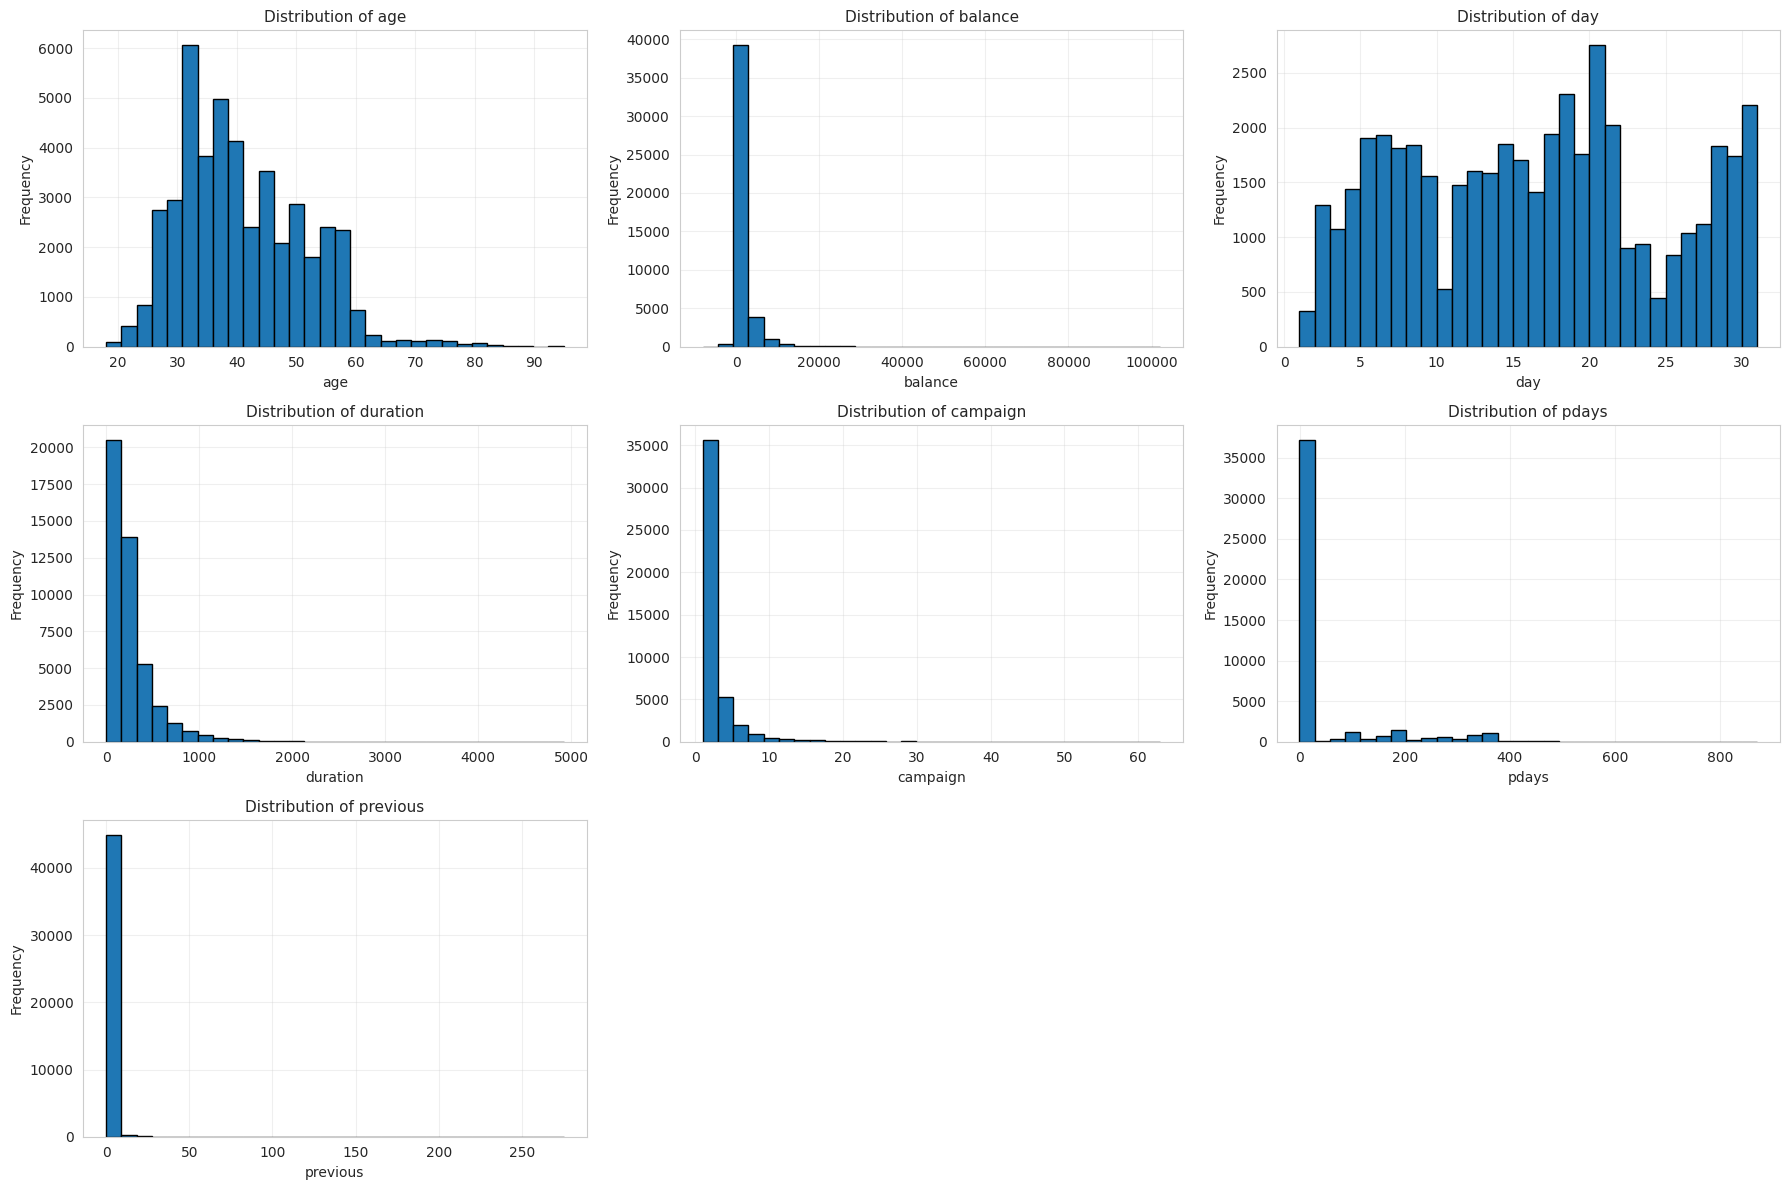

In [151]:
# Histograms for numerical variables

import math

n_cols = 3  # number of plots per row
n_rows = math.ceil(len(numerical_features) / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, 4 * n_rows))
axes = axes.flatten()

for i, col in enumerate(numerical_features):
    axes[i].hist(df[col], bins=30, edgecolor="black")
    axes[i].set_title(f"Distribution of {col}", fontsize=11)
    axes[i].set_xlabel(col)
    axes[i].set_ylabel("Frequency")
    axes[i].grid(True, alpha=0.3)

# Removing empty spaces
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

## **5.2** Boxplots of numerical variables

This section uses boxplots to identify outliers and spread in the numerical variables. Boxplots are useful for spotting extreme values and comparing the overall scale of each feature.

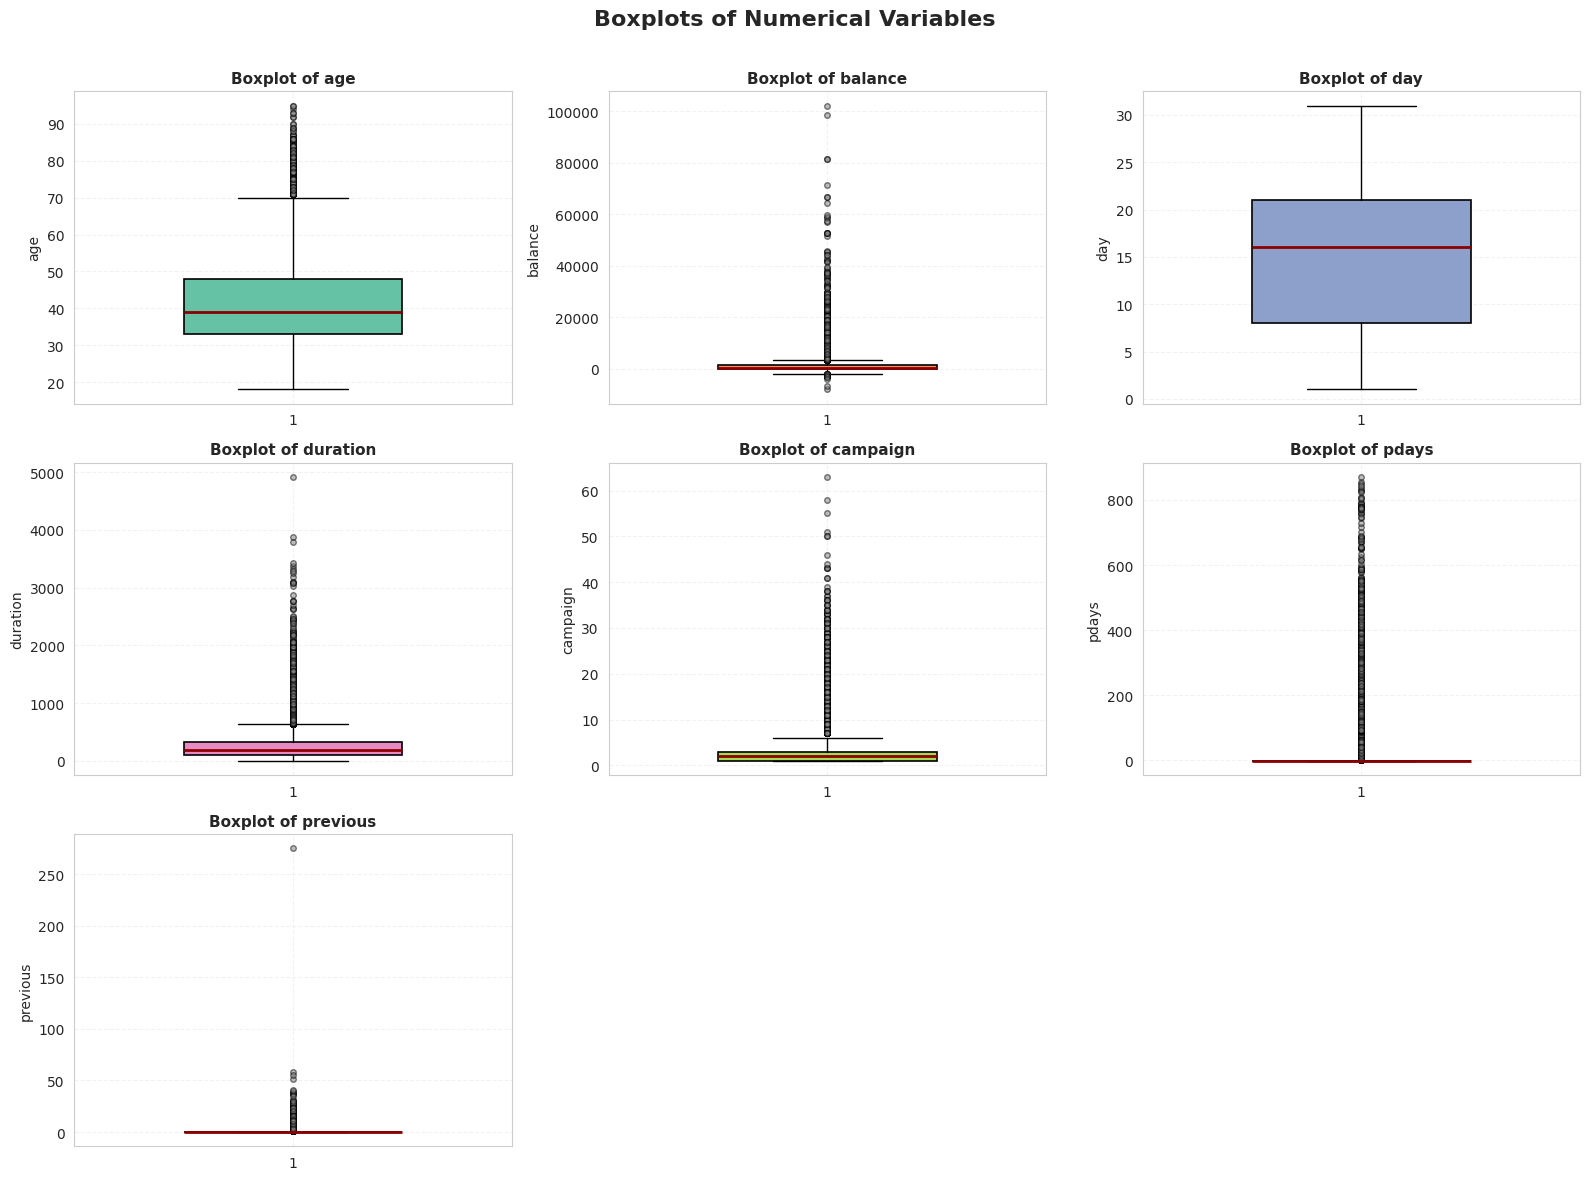

In [152]:
# boxplots of numerical variables

import math

n_cols = 3
n_rows = math.ceil(len(numerical_features) / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, 4 * n_rows))
axes = axes.flatten()

colors = ['#66c2a5', '#fc8d62', '#8da0cb', '#e78ac3', '#a6d854', '#ffd92f',
          '#e5c494', '#b3b3b3', '#1f78b4', '#33a02c', '#fb9a99', '#cab2d6']

for i, col in enumerate(numerical_features):
    bp = axes[i].boxplot(
        df[col].dropna(),
        vert=True,
        patch_artist=True,
        widths=0.5,
        boxprops=dict(facecolor=colors[i % len(colors)], edgecolor='black', linewidth=1.2),
        medianprops=dict(color='darkred', linewidth=2),
        whiskerprops=dict(color='black', linewidth=1),
        capprops=dict(color='black', linewidth=1),
        flierprops=dict(marker='o', markerfacecolor='gray', markersize=4, alpha=0.5)
    )

    axes[i].set_title(f"Boxplot of {col}", fontsize=11, fontweight='bold')
    axes[i].set_ylabel(col)
    axes[i].grid(True, alpha=0.25, linestyle='--')

# Removing empty subplots
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

fig.suptitle("Boxplots of Numerical Variables", fontsize=16, fontweight='bold')
plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.show()

## **5.3** Compare numerical features by target class

This section compares the mean and median values of numerical variables for customers who subscribed and those who did not subscribe. This helps identify whether numerical features show different patterns across the two classes.

In [153]:
# Mean and median by target class

mean_by_target = df.groupby("y")[numerical_features].mean().T
median_by_target = df.groupby("y")[numerical_features].median().T

print("Mean values by target class:")
display(mean_by_target)

print("\nMedian values by target class:")
display(median_by_target)

Mean values by target class:


y,no,yes
age,40.838986,41.670070
balance,1303.714969,1804.267915
day,15.892290,15.158253
duration,221.182806,537.294574
campaign,2.846350,2.141047
pdays,36.421372,68.702968
previous,0.502154,1.170354



Median values by target class:


y,no,yes
age,39.0,38.0
balance,417.0,733.0
day,16.0,15.0
duration,164.0,426.0
campaign,2.0,2.0
pdays,-1.0,-1.0
previous,0.0,0.0


## **5.4** Bar chart comparison of means by target class

This plot compares the average values of the numerical features across the target classes. It provides a quick visual indication of which variables may separate subscribers from non-subscribers.

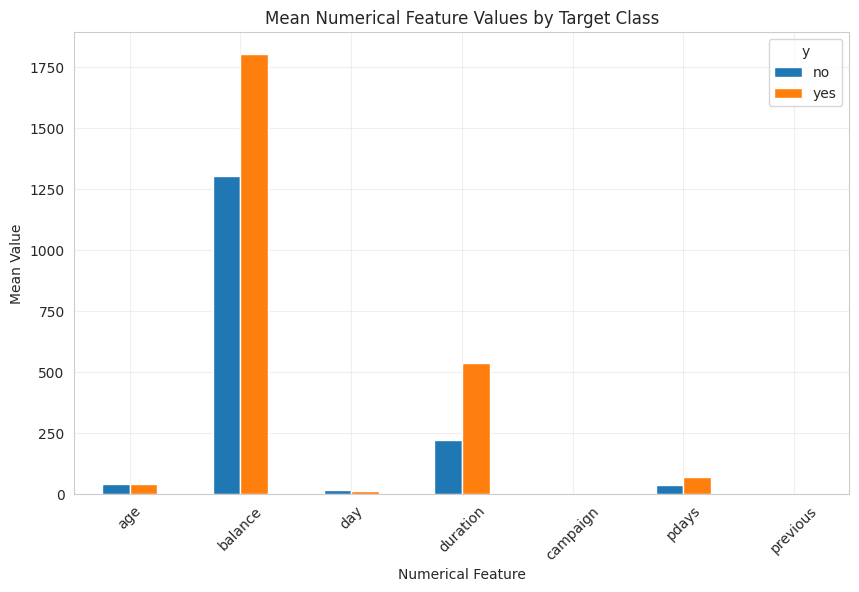

In [154]:
# Plot mean comparison by target class

mean_by_target.plot(kind="bar", figsize=(10, 6))
plt.title("Mean Numerical Feature Values by Target Class")
plt.xlabel("Numerical Feature")
plt.ylabel("Mean Value")
plt.xticks(rotation=45)
plt.grid(True, alpha=0.3)
plt.show()

## **5.5** Numerical feature correlation matrix

This section examines linear relationships between the numerical variables using a correlation matrix. Strong correlations may indicate redundancy or interaction between features.

Correlation matrix:


,age,balance,day,duration,campaign,pdays,previous
age,1.000000,0.097783,-0.009120,-0.004648,0.004760,-0.023758,0.001288
balance,0.097783,1.000000,0.004503,0.021560,-0.014578,0.003435,0.016674
day,-0.009120,0.004503,1.000000,-0.030206,0.162490,-0.093044,-0.051710
duration,-0.004648,0.021560,-0.030206,1.000000,-0.084570,-0.001565,0.001203
campaign,0.004760,-0.014578,0.162490,-0.084570,1.000000,-0.088628,-0.032855
pdays,-0.023758,0.003435,-0.093044,-0.001565,-0.088628,1.000000,0.454820
previous,0.001288,0.016674,-0.051710,0.001203,-0.032855,0.454820,1.000000


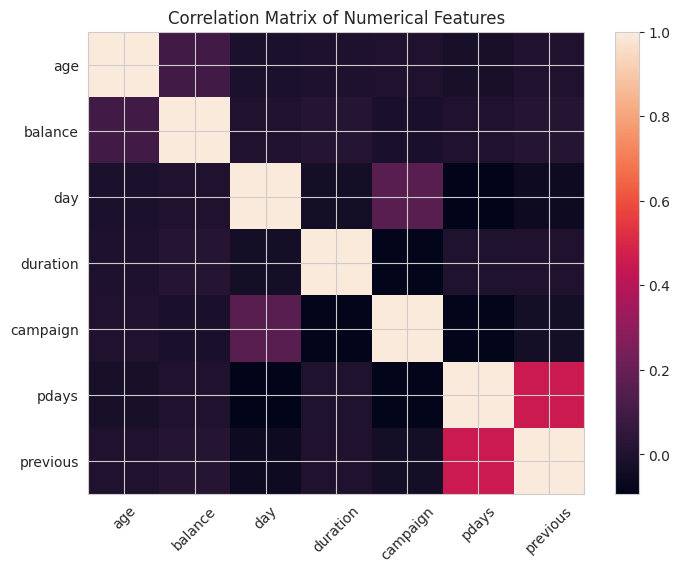

In [155]:
# Correlation matrix

corr_matrix = df[numerical_features].corr()

print("Correlation matrix:")
display(corr_matrix)

plt.figure(figsize=(8, 6))
plt.imshow(corr_matrix, interpolation="nearest", aspect="auto")
plt.colorbar()
plt.xticks(range(len(corr_matrix.columns)), corr_matrix.columns, rotation=45)
plt.yticks(range(len(corr_matrix.index)), corr_matrix.index)
plt.title("Correlation Matrix of Numerical Features")
plt.show()

## **5.6** Target-wise boxplots and histograms  for key numerical features

This section compares the distributions of selected numerical variables across the target classes. These visual comparisons help show whether customers who subscribed differ from those who did not in terms of age, balance, campaign duration, and contact history.

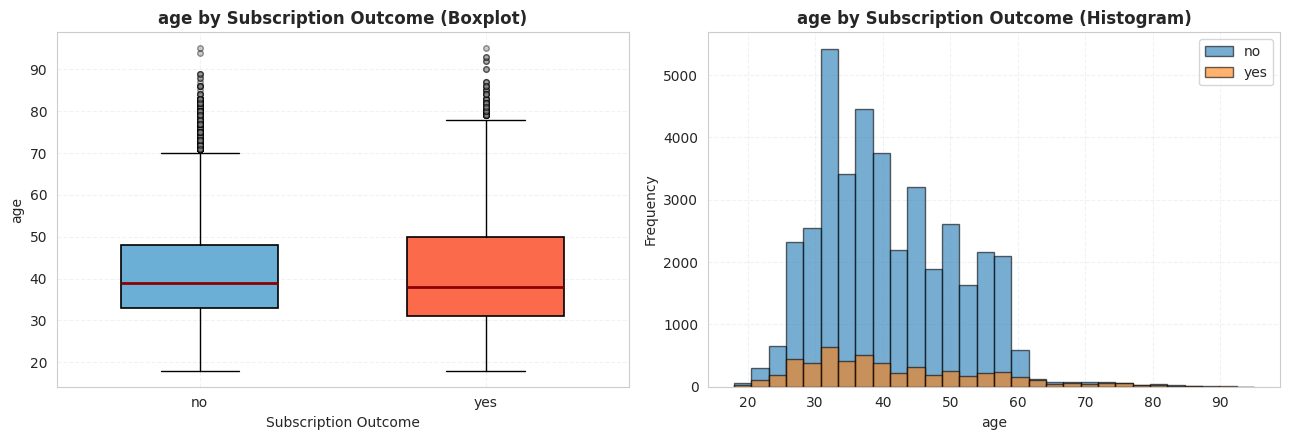

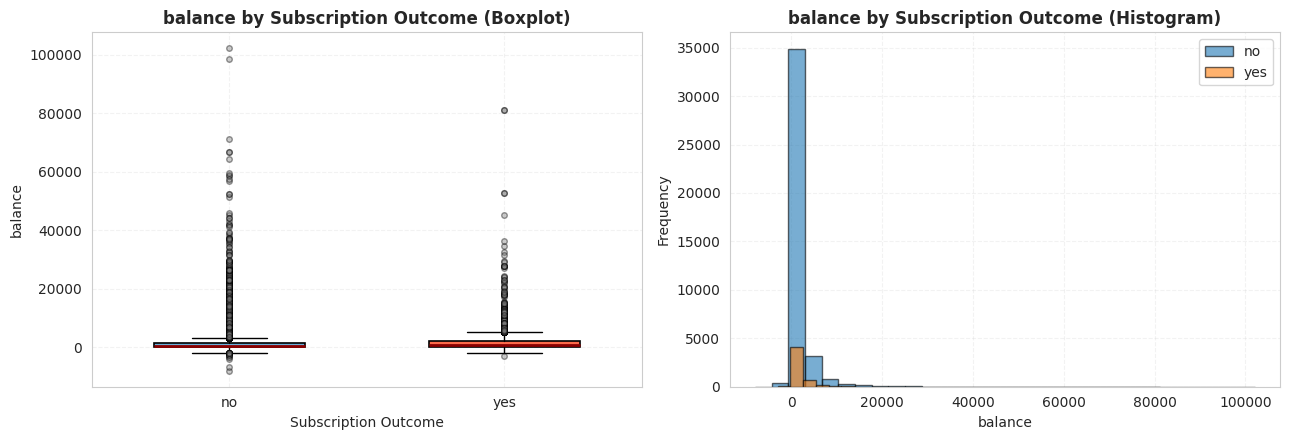

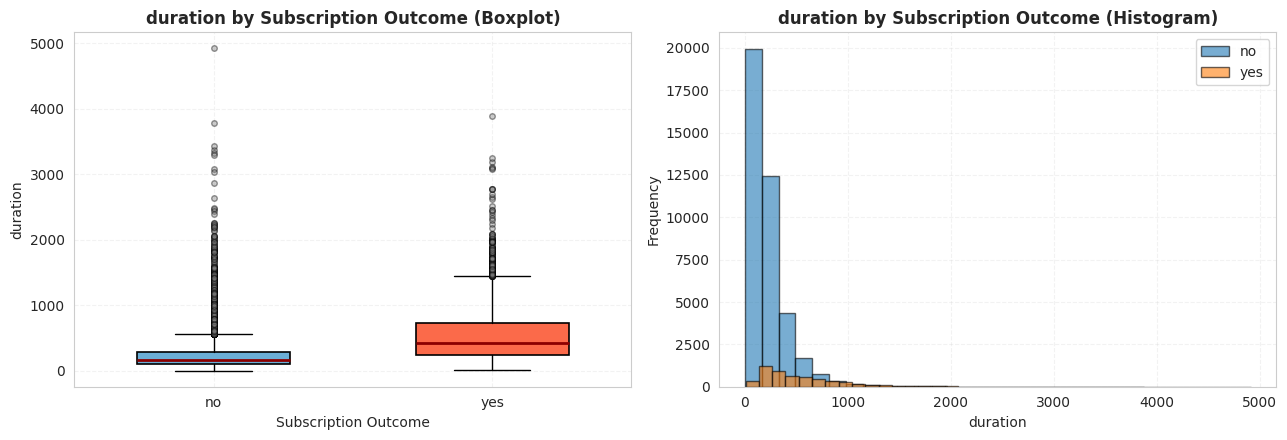

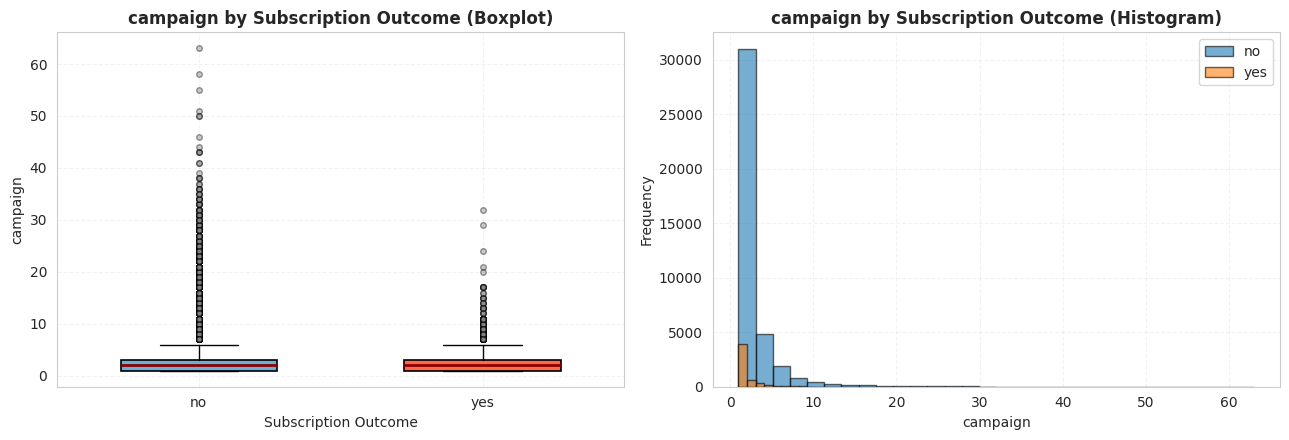

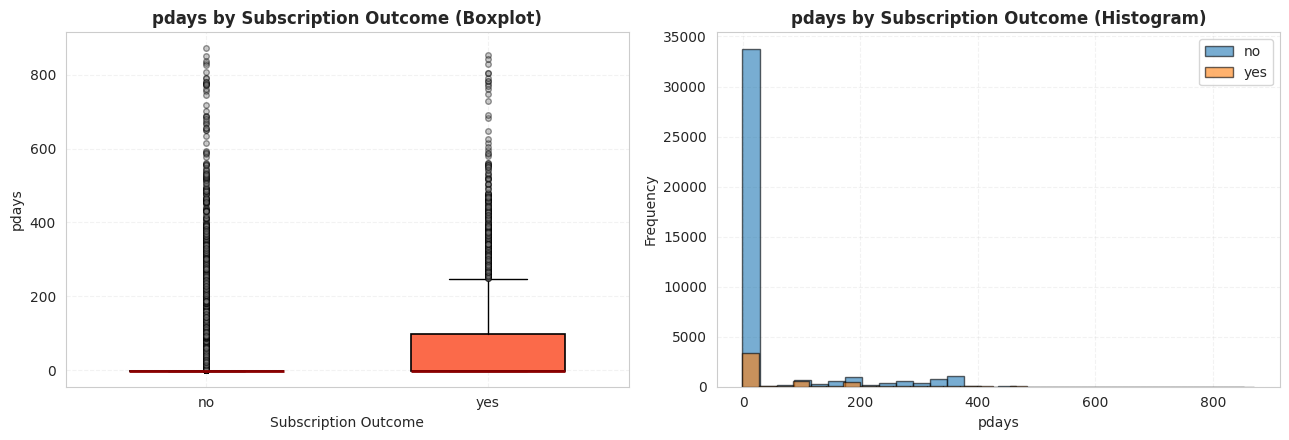

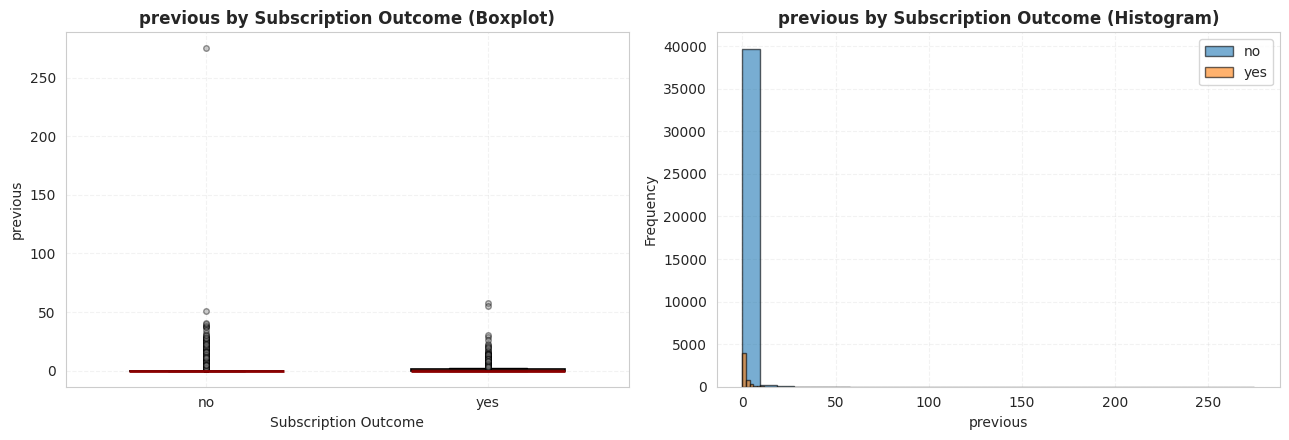

In [156]:
# Compare selected numerical features against target

key_numeric = ['age', 'balance', 'duration', 'campaign', 'pdays', 'previous']

colors = ["#6baed6", "#fb6a4a"]  # no, yes

for col in key_numeric:
    no_vals = df[df["y"] == "no"][col].dropna()
    yes_vals = df[df["y"] == "yes"][col].dropna()

    fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

    # Left: boxplot
    bp = axes[0].boxplot(
        [no_vals, yes_vals],
        tick_labels=["no", "yes"],
        patch_artist=True,
        widths=0.55,
        boxprops=dict(edgecolor="black", linewidth=1.2),
        medianprops=dict(color="darkred", linewidth=2),
        whiskerprops=dict(color="black", linewidth=1),
        capprops=dict(color="black", linewidth=1),
        flierprops=dict(marker='o', markerfacecolor='gray', markersize=4, alpha=0.4)
    )

    for patch, color in zip(bp["boxes"], colors):
        patch.set_facecolor(color)

    axes[0].set_title(f"{col} by Subscription Outcome (Boxplot)", fontweight="bold")
    axes[0].set_xlabel("Subscription Outcome")
    axes[0].set_ylabel(col)
    axes[0].grid(True, alpha=0.25, linestyle="--")

    # Right: overlaid histogram
    axes[1].hist(no_vals, bins=30, alpha=0.6, label="no", edgecolor="black")
    axes[1].hist(yes_vals, bins=30, alpha=0.6, label="yes", edgecolor="black")
    axes[1].set_title(f"{col} by Subscription Outcome (Histogram)", fontweight="bold")
    axes[1].set_xlabel(col)
    axes[1].set_ylabel("Frequency")
    axes[1].legend()
    axes[1].grid(True, alpha=0.25, linestyle="--")

    plt.tight_layout()
    plt.show()

## 5.7 Numerical EDA summary

This section prints a compact summary of the key numerical trends identified so far.

In [157]:
# Compact numerical summary

print("Mean values by target class:")
print(mean_by_target.round(2))

print("\nMedian values by target class:")
print(median_by_target.round(2))

print("\nCorrelation with duration:")
print(corr_matrix["duration"].sort_values(ascending=False).round(3))

print("\nCorrelation with balance:")
print(corr_matrix["balance"].sort_values(ascending=False).round(3))

Mean values by target class:
y              no      yes
age         40.84    41.67
balance   1303.71  1804.27
day         15.89    15.16
duration   221.18   537.29
campaign     2.85     2.14
pdays       36.42    68.70
previous     0.50     1.17

Median values by target class:
y            no    yes
age        39.0   38.0
balance   417.0  733.0
day        16.0   15.0
duration  164.0  426.0
campaign    2.0    2.0
pdays      -1.0   -1.0
previous    0.0    0.0

Correlation with duration:
duration    1.000
balance     0.022
previous    0.001
pdays      -0.002
age        -0.005
day        -0.030
campaign   -0.085
Name: duration, dtype: float64

Correlation with balance:
balance     1.000
age         0.098
duration    0.022
previous    0.017
day         0.005
pdays       0.003
campaign   -0.015
Name: balance, dtype: float64


# Section 6: Preprocessing Design and Feature Decisions

In this section, I prepare the dataset for machine learning by defining the target variable, creating a modelling copy of the data, and deciding how key features should be handled. Special attention is given to the variable `pdays`, which uses `-1` as a coded value, and to the variable `duration`, which will later be tested both with and without inclusion in the model.

In [158]:
# Create a modelling copy

df_model = df.copy()

print("Modelling dataset created.")
print("Shape:", df_model.shape)

Modelling dataset created.
Shape: (45211, 17)


## **6.1** Encode the target variable

This cell converts the target column into binary format so that it can be used in neural network training. The value `yes` is encoded as 1 and `no` is encoded as 0.

In [159]:
# Encode target

df_model["y_binary"] = df_model["y"].map({"no": 0, "yes": 1})

print("Target encoding completed.")
print(df_model[["y", "y_binary"]].head())

print("\nEncoded target distribution:")
print(df_model["y_binary"].value_counts())

Target encoding completed.
    y  y_binary
0  no         0
1  no         0
2  no         0
3  no         0
4  no         0

Encoded target distribution:
y_binary
0    39922
1     5289
Name: count, dtype: int64


## **6.2** Handle the special coded variable `pdays`

In the original dataset, `pdays = -1` indicates that the customer was not previously contacted. This is not a normal numerical value, so I create two new variables: one binary indicator showing whether the customer was previously contacted, and one cleaned numerical version of `pdays` where `-1` is replaced with 0.

In [160]:
# Handle pdays special coding

df_model["was_previously_contacted"] = (df_model["pdays"] != -1).astype(int)
df_model["pdays_clean"] = df_model["pdays"].replace(-1, 0)

print("New pdays-related features created.\n")

display(df_model[["pdays", "was_previously_contacted", "pdays_clean"]].head(10))

print("\nPreviously contacted flag counts:")
print(df_model["was_previously_contacted"].value_counts())

print("\nSummary of pdays_clean:")
display(df_model["pdays_clean"].describe())

New pdays-related features created.



,pdays,was_previously_contacted,pdays_clean
0,-1,0,0
1,-1,0,0
2,-1,0,0
3,-1,0,0
4,-1,0,0
5,-1,0,0
6,-1,0,0
7,-1,0,0
8,-1,0,0
9,-1,0,0



Previously contacted flag counts:
was_previously_contacted
0    36954
1     8257
Name: count, dtype: int64

Summary of pdays_clean:


,pdays_clean
count,45211.000000
mean,41.015195
std,99.792615
min,0.000000
25%,0.000000
50%,0.000000
75%,0.000000
max,871.000000


## **6.3** Define candidate input features

This cell defines the modelling feature sets. The original target column is removed, and the raw `pdays` variable is replaced by the engineered variables. Two feature versions are created: one including `duration` and one excluding it for comparison.

In [161]:
# Define feature sets

all_candidate_features = [col for col in df_model.columns if col not in ["y", "y_binary", "pdays"]]

features_with_duration = all_candidate_features.copy()
features_without_duration = [col for col in all_candidate_features if col != "duration"]

print("Number of features WITH duration:", len(features_with_duration))
print("Number of features WITHOUT duration:", len(features_without_duration))

print("\nFeatures WITH duration:")
print(features_with_duration)

print("\nFeatures WITHOUT duration:")
print(features_without_duration)

Number of features WITH duration: 17
Number of features WITHOUT duration: 16

Features WITH duration:
['age', 'job', 'marital', 'education', 'default', 'balance', 'housing', 'loan', 'contact', 'day', 'month', 'duration', 'campaign', 'previous', 'poutcome', 'was_previously_contacted', 'pdays_clean']

Features WITHOUT duration:
['age', 'job', 'marital', 'education', 'default', 'balance', 'housing', 'loan', 'contact', 'day', 'month', 'campaign', 'previous', 'poutcome', 'was_previously_contacted', 'pdays_clean']


## 6.4 Separate numerical and categorical features for each model version

This cell identifies which features are numerical and which are categorical. This is necessary because numerical variables will be scaled, while categorical variables will be encoded separately.

In [162]:
# Separate numerical and categorical features

numerical_with_duration = [
    "age", "balance", "day", "duration", "campaign", "previous",
    "was_previously_contacted", "pdays_clean"
]

categorical_with_duration = [col for col in features_with_duration if col not in numerical_with_duration]

numerical_without_duration = [
    "age", "balance", "day", "campaign", "previous",
    "was_previously_contacted", "pdays_clean"
]

categorical_without_duration = [col for col in features_without_duration if col not in numerical_without_duration]

print("Numerical features WITH duration:")
print(numerical_with_duration)

print("\nCategorical features WITH duration:")
print(categorical_with_duration)

print("\nNumerical features WITHOUT duration:")
print(numerical_without_duration)

print("\nCategorical features WITHOUT duration:")
print(categorical_without_duration)

Numerical features WITH duration:
['age', 'balance', 'day', 'duration', 'campaign', 'previous', 'was_previously_contacted', 'pdays_clean']

Categorical features WITH duration:
['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'poutcome']

Numerical features WITHOUT duration:
['age', 'balance', 'day', 'campaign', 'previous', 'was_previously_contacted', 'pdays_clean']

Categorical features WITHOUT duration:
['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'poutcome']


## 6.5 Create modelling matrices

This cell creates the final input matrices and target vector that will be used in later training and evaluation stages.

In [163]:
#  Create X and y objects

X_with_duration = df_model[features_with_duration].copy()
X_without_duration = df_model[features_without_duration].copy()
y = df_model["y_binary"].copy()

print("Shapes:")
print("X_with_duration:", X_with_duration.shape)
print("X_without_duration:", X_without_duration.shape)
print("y:", y.shape)

Shapes:
X_with_duration: (45211, 17)
X_without_duration: (45211, 16)
y: (45211,)


## 6.6 Preprocessing decision summary

This cell records the final preprocessing design decisions that will be used in the next stages of the project.

In [164]:
#  Preprocessing summary table

prep_summary = pd.DataFrame({
    "Decision Area": [
        "Target encoding",
        "Missing values",
        "Duplicates",
        "Unknown categories",
        "Special handling for pdays",
        "Duration comparison",
        "Categorical preprocessing",
        "Numerical preprocessing",
        "Class imbalance"
    ],
    "Decision": [
        "Encode y as 0/1",
        "No null values found",
        "No duplicates found",
        "Keep 'unknown' as a valid category",
        "Create was_previously_contacted and pdays_clean",
        "Train models with and without duration",
        "Use one-hot encoding later",
        "Scale numerical variables later",
        "Use stratified split and handle imbalance during training"
    ]
})

display(prep_summary)

,Decision Area,Decision
0,Target encoding,Encode y as 0/1
1,Missing values,No null values found
2,Duplicates,No duplicates found
3,Unknown categories,Keep 'unknown' as a valid category
4,Special handling for pdays,Create was_previously_contacted and pdays_clean
5,Duration comparison,Train models with and without duration
6,Categorical preprocessing,Use one-hot encoding later
7,Numerical preprocessing,Scale numerical variables later
8,Class imbalance,Use stratified split and handle imbalance duri...


# Section 7: Train, Validation, and Test Split

In this section, I divide the dataset into training, validation, and test sets. A stratified split is used to preserve the class imbalance ratio across all subsets. This ensures that model development, tuning, and final evaluation are carried out on separate data partitions.

#  7.1 - Import splitting function

from sklearn.model_selection import train_test_split

print("train_test_split imported successfully.")

In [165]:
#  Import splitting function

from sklearn.model_selection import train_test_split

print("train_test_split imported successfully.")

train_test_split imported successfully.


#  7.2 - Split data WITH duration

In [166]:
# Section 7.2 - Split data WITH duration

# Step 1: train vs temp
X_train_wd, X_temp_wd, y_train_wd, y_temp_wd = train_test_split(
    X_with_duration,
    y,
    test_size=0.30,
    stratify=y,
    random_state=42
)

# Step 2: validation vs test from temp
X_val_wd, X_test_wd, y_val_wd, y_test_wd = train_test_split(
    X_temp_wd,
    y_temp_wd,
    test_size=0.50,
    stratify=y_temp_wd,
    random_state=42
)

print("WITH duration split completed.")
print("X_train_wd:", X_train_wd.shape)
print("X_val_wd:", X_val_wd.shape)
print("X_test_wd:", X_test_wd.shape)
print("y_train_wd:", y_train_wd.shape)
print("y_val_wd:", y_val_wd.shape)
print("y_test_wd:", y_test_wd.shape)

WITH duration split completed.
X_train_wd: (31647, 17)
X_val_wd: (6782, 17)
X_test_wd: (6782, 17)
y_train_wd: (31647,)
y_val_wd: (6782,)
y_test_wd: (6782,)


## 7.3 Split the dataset without the duration feature

This cell creates train, validation, and test sets for the feature version that excludes `duration`. The same stratified splitting strategy is used to ensure a fair comparison between the two model versions.

In [167]:
# Split data WITHOUT duration

# Step 1: train vs temp
X_train_wod, X_temp_wod, y_train_wod, y_temp_wod = train_test_split(
    X_without_duration,
    y,
    test_size=0.30,
    stratify=y,
    random_state=42
)

# Step 2: validation vs test from temp
X_val_wod, X_test_wod, y_val_wod, y_test_wod = train_test_split(
    X_temp_wod,
    y_temp_wod,
    test_size=0.50,
    stratify=y_temp_wod,
    random_state=42
)

print("WITHOUT duration split completed.")
print("X_train_wod:", X_train_wod.shape)
print("X_val_wod:", X_val_wod.shape)
print("X_test_wod:", X_test_wod.shape)
print("y_train_wod:", y_train_wod.shape)
print("y_val_wod:", y_val_wod.shape)
print("y_test_wod:", y_test_wod.shape)

WITHOUT duration split completed.
X_train_wod: (31647, 16)
X_val_wod: (6782, 16)
X_test_wod: (6782, 16)
y_train_wod: (31647,)
y_val_wod: (6782,)
y_test_wod: (6782,)


## 7.4 Check class balance across splits

This cell verifies that the stratified split preserved the class distribution in the training, validation, and test sets. This is important because the target variable is imbalanced.

In [168]:
#  Function to check class balance

def class_distribution_report(name, y_series):
    counts = y_series.value_counts().sort_index()
    props = (y_series.value_counts(normalize=True).sort_index() * 100).round(2)

    print(f"\n{name}")
    print("Counts:")
    print(counts)
    print("Percentages:")
    print(props)

print("WITH duration - class balance check")
class_distribution_report("y_train_wd", y_train_wd)
class_distribution_report("y_val_wd", y_val_wd)
class_distribution_report("y_test_wd", y_test_wd)

print("\n" + "="*50)
print("WITHOUT duration - class balance check")
class_distribution_report("y_train_wod", y_train_wod)
class_distribution_report("y_val_wod", y_val_wod)
class_distribution_report("y_test_wod", y_test_wod)

WITH duration - class balance check

y_train_wd
Counts:
y_binary
0    27945
1     3702
Name: count, dtype: int64
Percentages:
y_binary
0    88.3
1    11.7
Name: proportion, dtype: float64

y_val_wd
Counts:
y_binary
0    5988
1     794
Name: count, dtype: int64
Percentages:
y_binary
0    88.29
1    11.71
Name: proportion, dtype: float64

y_test_wd
Counts:
y_binary
0    5989
1     793
Name: count, dtype: int64
Percentages:
y_binary
0    88.31
1    11.69
Name: proportion, dtype: float64

WITHOUT duration - class balance check

y_train_wod
Counts:
y_binary
0    27945
1     3702
Name: count, dtype: int64
Percentages:
y_binary
0    88.3
1    11.7
Name: proportion, dtype: float64

y_val_wod
Counts:
y_binary
0    5988
1     794
Name: count, dtype: int64
Percentages:
y_binary
0    88.29
1    11.71
Name: proportion, dtype: float64

y_test_wod
Counts:
y_binary
0    5989
1     793
Name: count, dtype: int64
Percentages:
y_binary
0    88.31
1    11.69
Name: proportion, dtype: float64


## 7.5 Confirm split proportions

This cell calculates the relative size of each subset to confirm that the data has been divided into approximately 70% training, 15% validation, and 15% test data.

In [169]:
# Confirm split proportions

total_rows = len(y)

split_summary = pd.DataFrame({
    "Subset": ["Train", "Validation", "Test"],
    "Rows (with duration)": [len(y_train_wd), len(y_val_wd), len(y_test_wd)],
    "Percentage (with duration)": [
        round(len(y_train_wd) / total_rows * 100, 2),
        round(len(y_val_wd) / total_rows * 100, 2),
        round(len(y_test_wd) / total_rows * 100, 2),
    ],
    "Rows (without duration)": [len(y_train_wod), len(y_val_wod), len(y_test_wod)],
    "Percentage (without duration)": [
        round(len(y_train_wod) / total_rows * 100, 2),
        round(len(y_val_wod) / total_rows * 100, 2),
        round(len(y_test_wod) / total_rows * 100, 2),
    ]
})

display(split_summary)

,Subset,Rows (with duration),Percentage (with duration),Rows (without duration),Percentage (without duration)
0,Train,31647,70.0,31647,70.0
1,Validation,6782,15.0,6782,15.0
2,Test,6782,15.0,6782,15.0


## 7.6 Split summary interpretation

This cell prints a compact interpretation of the splitting strategy used for the modelling workflow.

In [170]:
# Section 7.6 - Interpretation

print("Data splitting summary:")
print("- The dataset has been divided into training, validation, and test subsets.")
print("- Stratification has been used to preserve class imbalance ratios.")
print("- Separate splits have been created for both feature versions.")
print("- The test set will remain untouched until final evaluation.")

Data splitting summary:
- The dataset has been divided into training, validation, and test subsets.
- Stratification has been used to preserve class imbalance ratios.
- Separate splits have been created for both feature versions.
- The test set will remain untouched until final evaluation.


# Section 8: Encoding and Scaling

In this section, I preprocess the input features for neural network training. Categorical variables are transformed using one-hot encoding, while numerical variables are standardised using feature scaling. The preprocessing steps are fitted only on the training set to avoid data leakage, and then applied to the validation and test sets for both model versions.

In [171]:
#  Encoding and scaling for both model versions

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
import numpy as np


# 1. Build preprocessors

preprocessor_wd = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numerical_with_duration),
        ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False), categorical_with_duration)
    ]
)

preprocessor_wod = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numerical_without_duration),
        ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False), categorical_without_duration)
    ]
)


# 2. Fit on training data only

X_train_wd_processed = preprocessor_wd.fit_transform(X_train_wd)
X_val_wd_processed   = preprocessor_wd.transform(X_val_wd)
X_test_wd_processed  = preprocessor_wd.transform(X_test_wd)

X_train_wod_processed = preprocessor_wod.fit_transform(X_train_wod)
X_val_wod_processed   = preprocessor_wod.transform(X_val_wod)
X_test_wod_processed  = preprocessor_wod.transform(X_test_wod)


# 3. Convert to float32 for ANN

X_train_wd_processed = np.asarray(X_train_wd_processed, dtype=np.float32)
X_val_wd_processed   = np.asarray(X_val_wd_processed, dtype=np.float32)
X_test_wd_processed  = np.asarray(X_test_wd_processed, dtype=np.float32)

X_train_wod_processed = np.asarray(X_train_wod_processed, dtype=np.float32)
X_val_wod_processed   = np.asarray(X_val_wod_processed, dtype=np.float32)
X_test_wod_processed  = np.asarray(X_test_wod_processed, dtype=np.float32)

y_train_wd_np = np.asarray(y_train_wd, dtype=np.float32)
y_val_wd_np   = np.asarray(y_val_wd, dtype=np.float32)
y_test_wd_np  = np.asarray(y_test_wd, dtype=np.float32)

y_train_wod_np = np.asarray(y_train_wod, dtype=np.float32)
y_val_wod_np   = np.asarray(y_val_wod, dtype=np.float32)
y_test_wod_np  = np.asarray(y_test_wod, dtype=np.float32)


# 4. Get transformed feature names

feature_names_wd = preprocessor_wd.get_feature_names_out()
feature_names_wod = preprocessor_wod.get_feature_names_out()

# 5. Print summary

print("WITH duration - processed shapes")
print("X_train_wd_processed:", X_train_wd_processed.shape)
print("X_val_wd_processed:  ", X_val_wd_processed.shape)
print("X_test_wd_processed: ", X_test_wd_processed.shape)

print("\nWITHOUT duration - processed shapes")
print("X_train_wod_processed:", X_train_wod_processed.shape)
print("X_val_wod_processed:  ", X_val_wod_processed.shape)
print("X_test_wod_processed: ", X_test_wod_processed.shape)

print("\nSample transformed feature names WITH duration:")
print(feature_names_wd[:20])

print("\nSample transformed feature names WITHOUT duration:")
print(feature_names_wod[:20])

print("\nData types after processing:")
print("WITH duration:", X_train_wd_processed.dtype)
print("WITHOUT duration:", X_train_wod_processed.dtype)

print("\nNaN check:")
print("WITH duration - train NaNs:", np.isnan(X_train_wd_processed).sum())
print("WITHOUT duration - train NaNs:", np.isnan(X_train_wod_processed).sum())

WITH duration - processed shapes
X_train_wd_processed: (31647, 52)
X_val_wd_processed:   (6782, 52)
X_test_wd_processed:  (6782, 52)

WITHOUT duration - processed shapes
X_train_wod_processed: (31647, 51)
X_val_wod_processed:   (6782, 51)
X_test_wod_processed:  (6782, 51)

Sample transformed feature names WITH duration:
['num__age' 'num__balance' 'num__day' 'num__duration' 'num__campaign'
 'num__previous' 'num__was_previously_contacted' 'num__pdays_clean'
 'cat__job_admin.' 'cat__job_blue-collar' 'cat__job_entrepreneur'
 'cat__job_housemaid' 'cat__job_management' 'cat__job_retired'
 'cat__job_self-employed' 'cat__job_services' 'cat__job_student'
 'cat__job_technician' 'cat__job_unemployed' 'cat__job_unknown']

Sample transformed feature names WITHOUT duration:
['num__age' 'num__balance' 'num__day' 'num__campaign' 'num__previous'
 'num__was_previously_contacted' 'num__pdays_clean' 'cat__job_admin.'
 'cat__job_blue-collar' 'cat__job_entrepreneur' 'cat__job_housemaid'
 'cat__job_managemen

## Check the final ANN-ready matrices

This cell confirms that the processed feature matrices are fully numeric and ready to be used as inputs for neural network training.

In [172]:
print("First 3 rows of processed WITH-duration matrix:")
print(X_train_wd_processed[:3, :10])

print("\nFirst 3 rows of processed WITHOUT-duration matrix:")
print(X_train_wod_processed[:3, :10])

First 3 rows of processed WITH-duration matrix:
[[-0.93046093 -0.44381323 -0.8170392  -0.6801517  -0.5668498  -0.23477381
  -0.470453   -0.4095985   0.          0.        ]
 [-0.55387133 -0.3806249   0.14323561 -0.21454513 -0.5668498  -0.23477381
  -0.470453   -0.4095985   0.          0.        ]
 [-1.5894928  -0.41905904  0.02320126 -0.08756152 -0.24478345 -0.23477381
  -0.470453   -0.4095985   0.          1.        ]]

First 3 rows of processed WITHOUT-duration matrix:
[[-0.93046093 -0.44381323 -0.8170392  -0.5668498  -0.23477381 -0.470453
  -0.4095985   0.          0.          0.        ]
 [-0.55387133 -0.3806249   0.14323561 -0.5668498  -0.23477381 -0.470453
  -0.4095985   0.          0.          0.        ]
 [-1.5894928  -0.41905904  0.02320126 -0.24478345 -0.23477381 -0.470453
  -0.4095985   0.          1.          0.        ]]


# Section 9: Baseline MLP ANN Model (With Duration)

In this section, I build and train a baseline Multi-Layer Perceptron (MLP) using the feature set that includes the `duration` variable. This model serves as the first neural network benchmark before introducing additional comparison models and improved regularisation techniques.

All required Section 8 variables are available.
Baseline MLP model built successfully.



Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 32)             │         1,696 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,241 (8.75 KB)

 Trainable params: 2,241 (8.75 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/15
989/989 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.8971 - auc: 0.8889 - loss: 0.2425 - precision: 0.6085 - recall: 0.3379 - val_accuracy: 0.9030 - val_auc: 0.9167 - val_loss: 0.2161 - val_precision: 0.6388 - val_recall: 0.3942
Epoch 2/15
989/989 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.9041 - auc: 0.9181 - loss: 0.2149 - precision: 0.6275 - recall: 0.4433 - val_accuracy: 0.9073 - val_auc: 0.9207 - val_loss: 0.2124 - val_precision: 0.6627 - val_recall: 0.4232
Epoch 3/15
989/989 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.9058 - auc: 0.9237 - loss: 0.2087 - precision: 0.6335 - recall: 0.4627 - val_accuracy: 0.9084 - val_auc: 0.9230 - val_loss: 0.2094 - val_precision: 0.6629 - val_recall: 0.4433
Epoch 4/15
989/989 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.9076 - auc: 0.9276 - loss: 0.2040 - precision: 0.6399 - recall: 0.4800 - val_accuracy: 0.9071 - val_auc: 0.9250 - val_loss: 0.2074 - val_precision: 0.6513 - val_recall: 0.4446
Epoch 5/15
989/989 ━━━━━━━━━━━━━

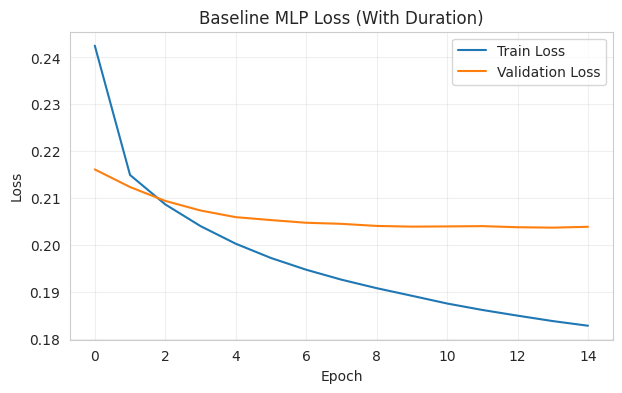

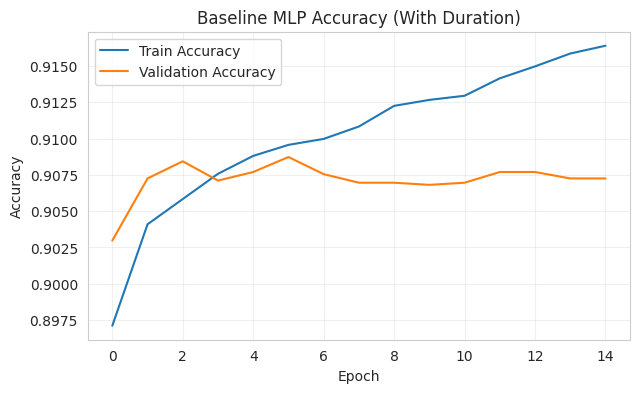


Baseline MLP validation performance:


,Metric,Validation Score
0,loss,0.203872
1,accuracy,0.907255
2,precision,0.641509
3,recall,0.471033
4,auc,0.928587



First 10 validation probabilities:
[0.0036 0.0004 0.0707 0.0096 0.0036 0.001  0.0521 0.0006 0.0194 0.0616]

First 10 validation predictions:
[0 0 0 0 0 0 0 0 0 0]

Final epoch summary:
Train loss: 0.1828
Val loss: 0.2039
Train accuracy: 0.9164
Val accuracy: 0.9073


In [173]:
#  Baseline MLP ANN with duration (robust rerun version)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf

from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense, Input
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.metrics import BinaryAccuracy, Precision, Recall, AUC

# 0. Safety checks

required_vars = [
    "X_train_wd_processed", "X_val_wd_processed",
    "y_train_wd_np", "y_val_wd_np"
]

missing_vars = [var for var in required_vars if var not in globals()]
if missing_vars:
    raise ValueError(
        f"These variables are missing: {missing_vars}. "
        "Please re-run Section 8 first."
    )

print("All required Section 8 variables are available.")


# 1. Clear old TensorFlow state and set seed

tf.keras.backend.clear_session()
tf.keras.utils.set_random_seed(42)


# 2. Build baseline MLP model

baseline_mlp_wd = Sequential([
    Input(shape=(X_train_wd_processed.shape[1],)),
    Dense(32, activation="relu"),
    Dense(16, activation="relu"),
    Dense(1, activation="sigmoid")
])

baseline_mlp_wd.compile(
    optimizer=Adam(learning_rate=0.001),
    loss="binary_crossentropy",
    metrics=[
        BinaryAccuracy(name="accuracy"),
        Precision(name="precision"),
        Recall(name="recall"),
        AUC(name="auc")
    ]
)

print("Baseline MLP model built successfully.\n")
baseline_mlp_wd.summary()


# 3. Train model

history_baseline_mlp_wd = baseline_mlp_wd.fit(
    X_train_wd_processed,
    y_train_wd_np,
    validation_data=(X_val_wd_processed, y_val_wd_np),
    epochs=15,
    batch_size=32,
    verbose=1
)


# 4. Plot training history

history_df = pd.DataFrame(history_baseline_mlp_wd.history)

plt.figure(figsize=(7, 4))
plt.plot(history_df["loss"], label="Train Loss")
plt.plot(history_df["val_loss"], label="Validation Loss")
plt.title("Baseline MLP Loss (With Duration)")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

plt.figure(figsize=(7, 4))
plt.plot(history_df["accuracy"], label="Train Accuracy")
plt.plot(history_df["val_accuracy"], label="Validation Accuracy")
plt.title("Baseline MLP Accuracy (With Duration)")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()


# 5. Evaluate on validation set

val_results_baseline_mlp_wd = baseline_mlp_wd.evaluate(
    X_val_wd_processed,
    y_val_wd_np,
    verbose=0
)

metric_names = ["loss", "accuracy", "precision", "recall", "auc"]
baseline_val_metrics_mlp_wd = pd.DataFrame({
    "Metric": metric_names,
    "Validation Score": val_results_baseline_mlp_wd
})

print("\nBaseline MLP validation performance:")
display(baseline_val_metrics_mlp_wd)


# 6. Save validation predictions

val_probs_baseline_mlp_wd = baseline_mlp_wd.predict(
    X_val_wd_processed,
    verbose=0
).ravel()

val_preds_baseline_mlp_wd = (val_probs_baseline_mlp_wd >= 0.5).astype(int)

print("\nFirst 10 validation probabilities:")
print(np.round(val_probs_baseline_mlp_wd[:10], 4))

print("\nFirst 10 validation predictions:")
print(val_preds_baseline_mlp_wd[:10])


# 7. Final epoch summary

print("\nFinal epoch summary:")
print("Train loss:", round(history_df['loss'].iloc[-1], 4))
print("Val loss:", round(history_df['val_loss'].iloc[-1], 4))
print("Train accuracy:", round(history_df['accuracy'].iloc[-1], 4))
print("Val accuracy:", round(history_df['val_accuracy'].iloc[-1], 4))

# Section 10 - SLP baseline with duration

All required variables are available.
SLP model built successfully.



Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 1)              │            53 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 53 (212.00 B)

 Trainable params: 53 (212.00 B)

 Non-trainable params: 0 (0.00 B)

Epoch 1/15
989/989 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.8640 - auc: 0.7824 - loss: 0.3381 - precision: 0.3667 - recall: 0.2239 - val_accuracy: 0.8910 - val_auc: 0.8908 - val_loss: 0.2619 - val_precision: 0.6536 - val_recall: 0.1474
Epoch 2/15
989/989 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.8966 - auc: 0.8949 - loss: 0.2554 - precision: 0.6737 - recall: 0.2258 - val_accuracy: 0.8991 - val_auc: 0.9048 - val_loss: 0.2460 - val_precision: 0.6910 - val_recall: 0.2506
Epoch 3/15
989/989 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.8997 - auc: 0.9030 - loss: 0.2460 - precision: 0.6665 - recall: 0.2855 - val_accuracy: 0.8999 - val_auc: 0.9071 - val_loss: 0.2411 - val_precision: 0.6716 - val_recall: 0.2834
Epoch 4/15
989/989 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.9008 - auc: 0.9056 - loss: 0.2426 - precision: 0.6617 - recall: 0.3117 - val_accuracy: 0.9008 - val_auc: 0.9083 - val_loss: 0.2391 - val_precision: 0.6695 - val_recall: 0.3010
Epoch 5/15
989/989 ━━━━━━━━━━━━━

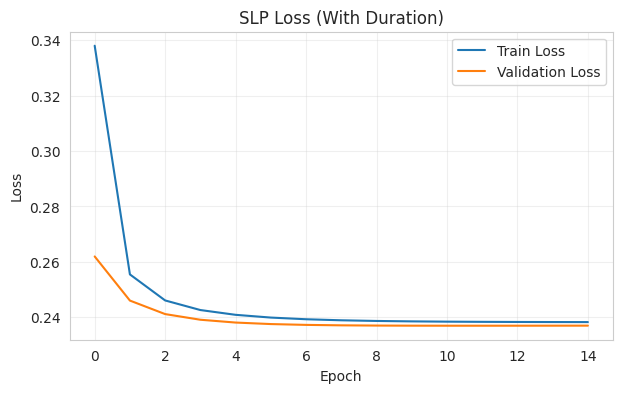

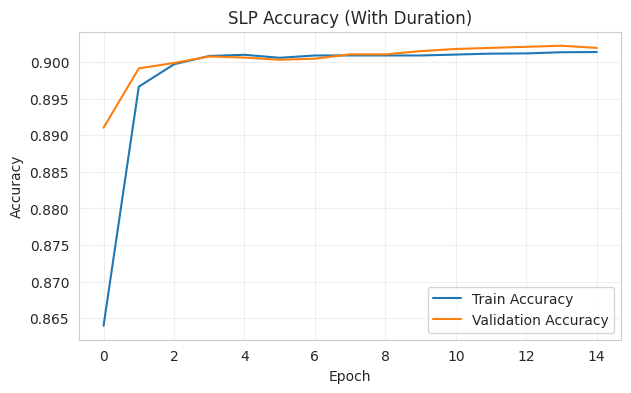


SLP validation performance:


,Metric,Validation Score
0,loss,0.236926
1,accuracy,0.901946
2,precision,0.659259
3,recall,0.336272
4,auc,0.906943



First 10 SLP validation probabilities:
[0.0277 0.0412 0.1801 0.0292 0.0088 0.0155 0.0738 0.0099 0.0496 0.0762]

First 10 SLP validation predictions:
[0 0 0 0 0 0 0 0 0 0]

Final epoch summary (SLP):
Train loss: 0.2382
Val loss: 0.2369
Train accuracy: 0.9014
Val accuracy: 0.9019

Validation comparison: SLP vs Baseline MLP


,Metric,SLP Validation,Baseline MLP Validation
0,loss,0.236926,0.203872
1,accuracy,0.901946,0.907255
2,precision,0.659259,0.641509
3,recall,0.336272,0.471033
4,auc,0.906943,0.928587


In [174]:
#  SLP baseline with duration

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf

from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense, Input
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.metrics import BinaryAccuracy, Precision, Recall, AUC


# 0. Safety checks

required_vars = [
    "X_train_wd_processed", "X_val_wd_processed",
    "y_train_wd_np", "y_val_wd_np",
    "baseline_val_metrics_mlp_wd"
]

missing_vars = [var for var in required_vars if var not in globals()]
if missing_vars:
    raise ValueError(
        f"These variables are missing: {missing_vars}. "
        "Please make sure Sections 8 and 9 have been run first."
    )

print("All required variables are available.")


# 1. Clear session and set seed

tf.keras.backend.clear_session()
tf.keras.utils.set_random_seed(42)


# 2. Build SLP model

slp_wd = Sequential([
    Input(shape=(X_train_wd_processed.shape[1],)),
    Dense(1, activation="sigmoid")
])

slp_wd.compile(
    optimizer=Adam(learning_rate=0.001),
    loss="binary_crossentropy",
    metrics=[
        BinaryAccuracy(name="accuracy"),
        Precision(name="precision"),
        Recall(name="recall"),
        AUC(name="auc")
    ]
)

print("SLP model built successfully.\n")
slp_wd.summary()


# 3. Train model

history_slp_wd = slp_wd.fit(
    X_train_wd_processed,
    y_train_wd_np,
    validation_data=(X_val_wd_processed, y_val_wd_np),
    epochs=15,
    batch_size=32,
    verbose=1
)


# 4. Plot training history

history_slp_df = pd.DataFrame(history_slp_wd.history)

plt.figure(figsize=(7, 4))
plt.plot(history_slp_df["loss"], label="Train Loss")
plt.plot(history_slp_df["val_loss"], label="Validation Loss")
plt.title("SLP Loss (With Duration)")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

plt.figure(figsize=(7, 4))
plt.plot(history_slp_df["accuracy"], label="Train Accuracy")
plt.plot(history_slp_df["val_accuracy"], label="Validation Accuracy")
plt.title("SLP Accuracy (With Duration)")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()


# 5. Evaluate on validation set

val_results_slp_wd = slp_wd.evaluate(
    X_val_wd_processed,
    y_val_wd_np,
    verbose=0
)

metric_names = ["loss", "accuracy", "precision", "recall", "auc"]
slp_val_metrics_wd = pd.DataFrame({
    "Metric": metric_names,
    "Validation Score": val_results_slp_wd
})

print("\nSLP validation performance:")
display(slp_val_metrics_wd)


# 6. Save validation predictions

val_probs_slp_wd = slp_wd.predict(X_val_wd_processed, verbose=0).ravel()
val_preds_slp_wd = (val_probs_slp_wd >= 0.5).astype(int)

print("\nFirst 10 SLP validation probabilities:")
print(np.round(val_probs_slp_wd[:10], 4))

print("\nFirst 10 SLP validation predictions:")
print(val_preds_slp_wd[:10])


# 7. Final epoch summary

print("\nFinal epoch summary (SLP):")
print("Train loss:", round(history_slp_df['loss'].iloc[-1], 4))
print("Val loss:", round(history_slp_df['val_loss'].iloc[-1], 4))
print("Train accuracy:", round(history_slp_df['accuracy'].iloc[-1], 4))
print("Val accuracy:", round(history_slp_df['val_accuracy'].iloc[-1], 4))


# 8. Quick comparison: SLP vs Baseline MLP

comparison_df = pd.DataFrame({
    "Metric": metric_names,
    "SLP Validation": val_results_slp_wd,
    "Baseline MLP Validation": baseline_val_metrics_mlp_wd["Validation Score"].values
})

print("\nValidation comparison: SLP vs Baseline MLP")
display(comparison_df)

# Section 11: Improved MLP ANN Model (With Duration)

In this section, I develop an improved Multi-Layer Perceptron (MLP) using the feature set that includes the `duration` variable. Compared with the baseline network, this version introduces a deeper architecture, dropout regularisation, early stopping, and class weighting. These improvements are intended to reduce overfitting, address class imbalance, and improve generalisation performance.

All required variables are available.
Class weights:
{0: 0.5662372517444981, 1: 4.274311183144246}

Improved MLP model built successfully.



Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │         3,392 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6,017 (23.50 KB)

 Trainable params: 6,017 (23.50 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/30
989/989 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.7590 - auc: 0.8686 - loss: 0.4554 - precision: 0.3055 - recall: 0.8325 - val_accuracy: 0.8085 - val_auc: 0.9150 - val_loss: 0.3676 - val_precision: 0.3675 - val_recall: 0.8816
Epoch 2/30
989/989 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.8039 - auc: 0.9085 - loss: 0.3792 - precision: 0.3621 - recall: 0.8884 - val_accuracy: 0.7983 - val_auc: 0.9209 - val_loss: 0.3861 - val_precision: 0.3582 - val_recall: 0.9131
Epoch 3/30
989/989 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.8098 - auc: 0.9164 - loss: 0.3607 - precision: 0.3707 - recall: 0.8971 - val_accuracy: 0.8054 - val_auc: 0.9237 - val_loss: 0.3712 - val_precision: 0.3674 - val_recall: 0.9181
Epoch 4/30
989/989 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.8129 - auc: 0.9184 - loss: 0.3549 - precision: 0.3753 - recall: 0.9017 - val_accuracy: 0.8228 - val_auc: 0.9260 - val_loss: 0.3409 - val_precision: 0.3897 - val_recall: 0.9081
Epoch 5/30
989/989 ━━━━━━━━━━━━━

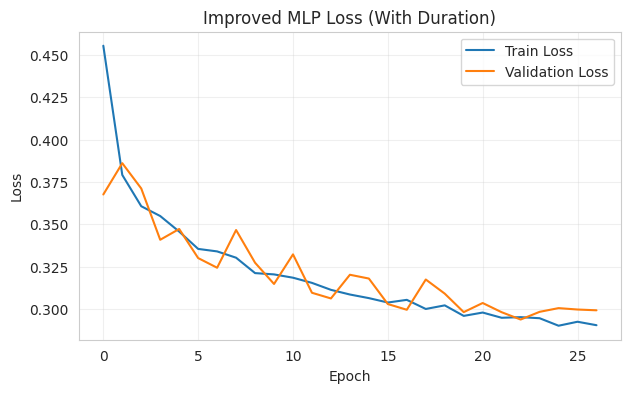

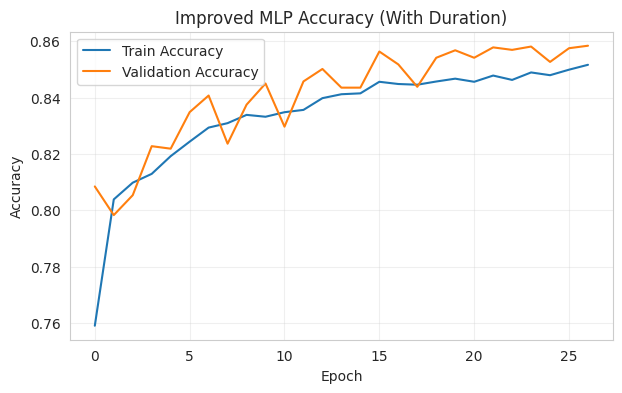


Improved MLP validation performance:


,Metric,Validation Score
0,loss,0.293844
1,accuracy,0.856974
2,precision,0.444374
3,recall,0.885390
4,auc,0.933820



First 10 improved MLP validation probabilities:
[0.0013 0.0028 0.417  0.0095 0.0038 0.0023 0.0371 0.0025 0.1295 0.4039]

First 10 improved MLP validation predictions:
[0 0 0 0 0 0 0 0 0 0]

Final epoch summary (Improved MLP):
Train loss: 0.2905
Val loss: 0.2993
Train accuracy: 0.8517
Val accuracy: 0.8584

Validation comparison: SLP vs Baseline MLP vs Improved MLP


,Metric,SLP Validation,Baseline MLP Validation,Improved MLP Validation
0,loss,0.236926,0.203872,0.293844
1,accuracy,0.901946,0.907255,0.856974
2,precision,0.659259,0.641509,0.444374
3,recall,0.336272,0.471033,0.885390
4,auc,0.906943,0.928587,0.933820


In [175]:
 #  Improved MLP ANN with duration

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf

from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense, Dropout, Input
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.metrics import BinaryAccuracy, Precision, Recall, AUC
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.utils.class_weight import compute_class_weight


# 0. Safety checks

required_vars = [
    "X_train_wd_processed", "X_val_wd_processed",
    "y_train_wd_np", "y_val_wd_np",
    "baseline_val_metrics_mlp_wd", "slp_val_metrics_wd"
]

missing_vars = [var for var in required_vars if var not in globals()]
if missing_vars:
    raise ValueError(
        f"These variables are missing: {missing_vars}. "
        "Please make sure Sections 8, 9 and 10 have been run first."
    )

print("All required variables are available.")


# 1. Clear session and set seed

tf.keras.backend.clear_session()
tf.keras.utils.set_random_seed(42)


# 2. Compute class weights

classes = np.unique(y_train_wd_np)
weights = compute_class_weight(
    class_weight="balanced",
    classes=classes,
    y=y_train_wd_np
)

class_weight_dict = {int(cls): float(w) for cls, w in zip(classes, weights)}

print("Class weights:")
print(class_weight_dict)


# 3. Build improved MLP model

improved_mlp_wd = Sequential([
    Input(shape=(X_train_wd_processed.shape[1],)),
    Dense(64, activation="relu"),
    Dropout(0.30),
    Dense(32, activation="relu"),
    Dropout(0.20),
    Dense(16, activation="relu"),
    Dense(1, activation="sigmoid")
])

improved_mlp_wd.compile(
    optimizer=Adam(learning_rate=0.001),
    loss="binary_crossentropy",
    metrics=[
        BinaryAccuracy(name="accuracy"),
        Precision(name="precision"),
        Recall(name="recall"),
        AUC(name="auc")
    ]
)

print("\nImproved MLP model built successfully.\n")
improved_mlp_wd.summary()


# 4. Early stopping

early_stopping = EarlyStopping(
    monitor="val_loss",
    patience=4,
    restore_best_weights=True
)


# 5. Train model

history_improved_mlp_wd = improved_mlp_wd.fit(
    X_train_wd_processed,
    y_train_wd_np,
    validation_data=(X_val_wd_processed, y_val_wd_np),
    epochs=30,
    batch_size=32,
    class_weight=class_weight_dict,
    callbacks=[early_stopping],
    verbose=1
)

# 6. Plot training history

history_improved_df = pd.DataFrame(history_improved_mlp_wd.history)

plt.figure(figsize=(7, 4))
plt.plot(history_improved_df["loss"], label="Train Loss")
plt.plot(history_improved_df["val_loss"], label="Validation Loss")
plt.title("Improved MLP Loss (With Duration)")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

plt.figure(figsize=(7, 4))
plt.plot(history_improved_df["accuracy"], label="Train Accuracy")
plt.plot(history_improved_df["val_accuracy"], label="Validation Accuracy")
plt.title("Improved MLP Accuracy (With Duration)")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# 7. Evaluate on validation set

val_results_improved_mlp_wd = improved_mlp_wd.evaluate(
    X_val_wd_processed,
    y_val_wd_np,
    verbose=0
)

metric_names = ["loss", "accuracy", "precision", "recall", "auc"]
improved_val_metrics_mlp_wd = pd.DataFrame({
    "Metric": metric_names,
    "Validation Score": val_results_improved_mlp_wd
})

print("\nImproved MLP validation performance:")
display(improved_val_metrics_mlp_wd)

# 8. Save validation predictions

val_probs_improved_mlp_wd = improved_mlp_wd.predict(
    X_val_wd_processed,
    verbose=0
).ravel()

val_preds_improved_mlp_wd = (val_probs_improved_mlp_wd >= 0.5).astype(int)

print("\nFirst 10 improved MLP validation probabilities:")
print(np.round(val_probs_improved_mlp_wd[:10], 4))

print("\nFirst 10 improved MLP validation predictions:")
print(val_preds_improved_mlp_wd[:10])


# 9. Final epoch summary

print("\nFinal epoch summary (Improved MLP):")
print("Train loss:", round(history_improved_df['loss'].iloc[-1], 4))
print("Val loss:", round(history_improved_df['val_loss'].iloc[-1], 4))
print("Train accuracy:", round(history_improved_df['accuracy'].iloc[-1], 4))
print("Val accuracy:", round(history_improved_df['val_accuracy'].iloc[-1], 4))


# 10. Compare all three neural models

comparison_all_models = pd.DataFrame({
    "Metric": metric_names,
    "SLP Validation": slp_val_metrics_wd["Validation Score"].values,
    "Baseline MLP Validation": baseline_val_metrics_mlp_wd["Validation Score"].values,
    "Improved MLP Validation": improved_val_metrics_mlp_wd["Validation Score"].values
})

print("\nValidation comparison: SLP vs Baseline MLP vs Improved MLP")
display(comparison_all_models)

# Section 11B: Part B  Generative AI Guidance

In Part B, I extend the modelling stage of the project by using Generative AI as a guidance tool. The aim is not to replace my own modelling decisions, but to investigate whether AI-supported suggestions can help improve ANN architecture design, hyperparameter choices, evaluation strategy, and uncertainty analysis for the Bank Marketing dataset.

To ensure a fair comparison with Part A, the same dataset, feature engineering decisions, preprocessing pipeline, train/validation/test split, encoding, and scaling steps are retained. This means that the only major change introduced in Part B is the use of Generative AI during the model development stage.

The Generative AI support will be used for:
- suggesting a stronger ANN architecture,
- recommending suitable hyperparameter settings,
- identifying appropriate evaluation metrics for an imbalanced binary classification task,
- and proposing simple methods for identifying ambiguous or uncertain predictions.

These suggestions will not be accepted without proper reasoning. Instead, they will be reviewed critically, and only those that are appropriate for tabular binary classification will be adopted. Suggestions that are unsuitable for this dataset or this coursework context will be rejected and explained.

The Part B workflow therefore adds one new GenAI-guided ANN model before the shared evaluation stage. This allows the new model to be tested using the same procedure as the Part A models, so that all models can be compared fairly in the later sections.

# Section 11C: Prompt Log for Generative AI Guidance

To make the use of Generative AI transparent, I recorded the main prompts used during Part B. These prompts were designed to obtain guidance on ANN architecture design, hyperparameter tuning, evaluation metrics, and ambiguity analysis for the Bank Marketing dataset.

The purpose of recording these prompts is to show that Generative AI was used as a support tool rather than as a replacement for independent judgement. The prompts focus on obtaining modelling suggestions that are relevant to a tabular binary classification problem with class imbalance.

## Prompts Used

**Prompt 1: ANN architecture design**  
I am working on the UCI Bank Marketing dataset for a binary classification ANN coursework project. The dataset is tabular, the target variable is imbalanced, and I have already built:  
1) a single-layer perceptron (SLP)  
2) a baseline MLP  
3) an improved MLP with dropout and class weights  

Suggest one stronger feedforward ANN architecture for Part B using the same preprocessed tabular inputs. Please justify:  
- number of hidden layers  
- number of neurons  
- activation functions  
- dropout  
- whether batch normalization should be used  
- why this architecture may be suitable for imbalanced tabular binary classification.  

**Prompt 2: Hyperparameter tuning**  
For a binary classification ANN on the UCI Bank Marketing dataset with class imbalance, suggest realistic hyperparameter settings for:  
- learning rate  
- batch size  
- epochs  
- early stopping  
- ReduceLROnPlateau  
- dropout levels  
- class weights  

I want settings appropriate for a coursework project and suitable for comparison against simpler ANN baselines.  

**Prompt 3: Evaluation metrics**  
I am evaluating ANN models on an imbalanced binary classification problem using the Bank Marketing dataset. Beyond accuracy, which evaluation metrics should I use and why?  

Please include:  
- precision  
- recall  
- F1-score  
- balanced accuracy  
- ROC-AUC  
- PR-AUC  
- confusion matrix analysis  
- how to interpret a model with lower accuracy but higher recall and F1-score.  

**Prompt 4: Ambiguity / uncertainty analysis**  
For a binary ANN classifier with sigmoid output probabilities, suggest simple and interpretable ways to identify ambiguous or uncertain predictions. I want techniques suitable for coursework, not advanced research-only methods.  

Please explain how:  
- predictions close to 0.5  
- fixed ambiguity bands such as 0.40 to 0.60  
- confidence-based error inspection  

can be used.  

**Prompt 5: Critical checking of AI suggestions**  
I do not want to blindly copy AI suggestions. For tabular binary classification using an ANN, which suggested ideas should be critically checked or possibly rejected, and why?  

These prompts were used to guide the design of the Part B model, while the final choices were still checked against the dataset characteristics, coursework requirements, and the need for fair comparison with Part A.

# Section 11D: Adopted and Rejected AI Suggestions

After reviewing the Generative AI responses, I did not adopt every suggestion automatically. Instead, I selected only the ideas that were appropriate for a tabular binary classification problem and suitable for fair comparison with Part A.

## AI suggestions adopted

**1. Use a deeper feedforward MLP**  
This suggestion was adopted because Part B needed a model that was more advanced than the earlier Part A baselines, while still remaining suitable for structured tabular data.

**2. Add dropout regularisation**  
This was adopted because dropout can reduce overfitting and improve generalisation, especially when the network becomes deeper.

**3. Use batch normalization**  
This suggestion was adopted because batch normalization can help stabilise training and improve learning efficiency in deeper feedforward networks.

**4. Use class weights**  
This was adopted because the Bank Marketing dataset is imbalanced, so class weighting helps the model pay more attention to the minority “yes” class.

**5. Use early stopping**  
This was adopted because it helps prevent unnecessary training and reduces the risk of overfitting when validation performance stops improving.

**6. Use ReduceLROnPlateau**  
This was adopted because lowering the learning rate when validation loss stops improving can help the model converge more effectively.

**7. Use multiple evaluation metrics beyond accuracy**  
This was adopted because accuracy alone is not sufficient for an imbalanced binary classification problem. Metrics such as recall, F1-score, balanced accuracy, ROC-AUC, and PR-AUC give a more complete view of performance.

**8. Use probability-based ambiguity analysis**  
This was adopted because predictions close to 0.5 are easy to interpret as uncertain cases, which directly supports the coursework requirement to identify ambiguous or difficult predictions.

## AI suggestions rejected

**1. Use CNN-based architecture**  
This was rejected because CNNs are mainly designed for image-like spatial data, while the Bank Marketing dataset is structured tabular data.

**2. Use RNN or LSTM-based architecture**  
This was rejected because the dataset is not sequential or time-series data, so recurrent architectures would not be appropriate.

**3. Use a very deep ANN with many hidden layers**  
This was rejected because such complexity is unnecessary for this coursework dataset and would increase the risk of overfitting without clear justification.

**4. Change the preprocessing pipeline completely**  
This was rejected because Part B needed to remain directly comparable with Part A. Keeping the same preprocessing pipeline ensures that any performance difference is mainly due to the new AI-guided model rather than changes in data preparation.

Overall, Generative AI was useful for expanding the range of modelling ideas, but all final decisions still required critical judgement. This ensured that Part B remained academically justified rather than simply AI-generated.

# Section 11E: GenAI-Guided Advanced MLP Model

Using the prompts documented in the previous section, I designed one new ANN model for Part B based on Generative AI guidance. The aim was to create a stronger feedforward network than the earlier Part A models, while still keeping the design suitable for structured tabular data.

The main ideas adopted from the AI guidance were:
- a deeper feedforward MLP architecture,
- dropout regularisation,
- batch normalization,
- class weighting for the imbalanced target,
- early stopping,
- and learning-rate reduction during training.

The suggested ideas were filtered and adapted so that the final architecture remained reasonable for the Bank Marketing dataset and directly comparable with the Part A models.

The model below is therefore the new Part B model that will later be compared against the SLP, baseline MLP, and improved MLP developed independently in Part A.

All required processed datasets are available.
Training shape: (31647, 52)
Validation shape: (6782, 52)

Class weights being used:
{0: 0.5662372517444981, 1: 4.274311183144246}

GenAI-guided model summary:


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │         6,784 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 17,921 (70.00 KB)

 Trainable params: 17,537 (68.50 KB)

 Non-trainable params: 384 (1.50 KB)

Epoch 1/40
495/495 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.7186 - auc: 0.8382 - loss: 0.5058 - precision: 0.2676 - recall: 0.8093 - val_accuracy: 0.8384 - val_auc: 0.9119 - val_loss: 0.3428 - val_precision: 0.4067 - val_recall: 0.8287 - learning_rate: 5.0000e-04
Epoch 2/40
495/495 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.7918 - auc: 0.8933 - loss: 0.4080 - precision: 0.3440 - recall: 0.8595 - val_accuracy: 0.8312 - val_auc: 0.9184 - val_loss: 0.3259 - val_precision: 0.3975 - val_recall: 0.8577 - learning_rate: 5.0000e-04
Epoch 3/40
495/495 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.7978 - auc: 0.9039 - loss: 0.3856 - precision: 0.3537 - recall: 0.8806 - val_accuracy: 0.8321 - val_auc: 0.9218 - val_loss: 0.3235 - val_precision: 0.4001 - val_recall: 0.8703 - learning_rate: 5.0000e-04
Epoch 4/40
495/495 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.8058 - auc: 0.9119 - loss: 0.3652 - precision: 0.3651 - recall: 0.8941 - val_accuracy: 0.8326 - val_auc: 0.9242 - val_loss: 

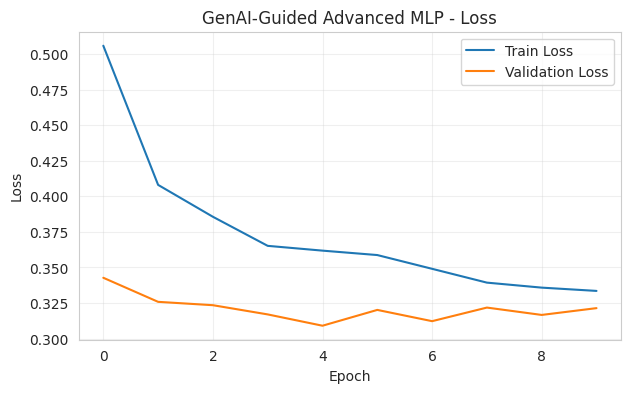

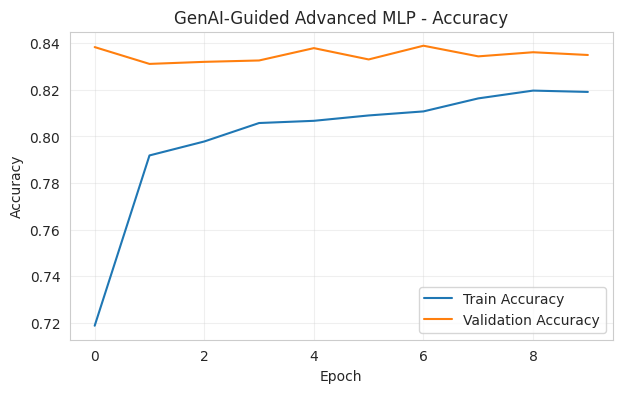


Validation performance of the GenAI-guided model:


,Metric,Validation Score
0,accuracy,0.837953
1,auc,0.924884
2,loss,0.309088
3,precision,0.409388
4,recall,0.867758


In [176]:

# Section 11E - Build and train the GenAI-guided advanced MLP


# What this cell does:
# This cell builds the new Part B neural network using the same
# processed input data from Part A. It then trains the model,
# plots the learning curves, and shows a quick validation summary.

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Dense, Dropout, BatchNormalization
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.metrics import BinaryAccuracy, Precision, Recall, AUC
from sklearn.utils.class_weight import compute_class_weight


# Step 1: Quick safety check
# Make sure the processed training/validation data already exists
# from Part A before building the new model.

required_variables = [
    "X_train_wd_processed",
    "X_val_wd_processed",
    "y_train_wd_np",
    "y_val_wd_np"
]

missing_variables = [var for var in required_variables if var not in globals()]

if missing_variables:
    raise ValueError(
        f"These variables are missing: {missing_variables}. "
        "Please run the earlier Part A preprocessing and model sections first."
    )

print("All required processed datasets are available.")
print("Training shape:", X_train_wd_processed.shape)
print("Validation shape:", X_val_wd_processed.shape)


# Step 2: Reset random state for cleaner reproducibility

tf.keras.backend.clear_session()
tf.keras.utils.set_random_seed(42)


# Step 3: Compute class weights
# Because the dataset is imbalanced, class weights help the
# model pay more attention to the minority 'yes' class.

classes = np.unique(y_train_wd_np)
class_weights_array = compute_class_weight(
    class_weight="balanced",
    classes=classes,
    y=y_train_wd_np
)

class_weight_dict_genai = {
    int(cls): float(weight)
    for cls, weight in zip(classes, class_weights_array)
}

print("\nClass weights being used:")
print(class_weight_dict_genai)


# Step 4: Build the GenAI-guided advanced MLP
# This is deeper than the earlier baseline models but still
# sensible for tabular binary classification.

genai_mlp_wd = Sequential([
    Input(shape=(X_train_wd_processed.shape[1],)),

    Dense(128, activation="relu"),
    BatchNormalization(),
    Dropout(0.30),

    Dense(64, activation="relu"),
    BatchNormalization(),
    Dropout(0.25),

    Dense(32, activation="relu"),
    Dropout(0.15),

    Dense(1, activation="sigmoid")
])


# Step 5: Compile the model
# We keep binary crossentropy because this is a binary
# classification task, and we track several useful metrics.

genai_mlp_wd.compile(
    optimizer=Adam(learning_rate=0.0005),
    loss="binary_crossentropy",
    metrics=[
        BinaryAccuracy(name="accuracy"),
        Precision(name="precision"),
        Recall(name="recall"),
        AUC(name="auc")
    ]
)

print("\nGenAI-guided model summary:")
genai_mlp_wd.summary()


# Step 6: Set callbacks
# Early stopping prevents wasted training once validation
# performance stops improving.
# ReduceLROnPlateau lowers the learning rate if learning stalls.

early_stopping_genai = EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True
)

reduce_lr_genai = ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.5,
    patience=2,
    min_lr=1e-6,
    verbose=1
)


# Step 7: Train the model
# We train on the same Part A processed data so the comparison
# stays fair.

history_genai_mlp_wd = genai_mlp_wd.fit(
    X_train_wd_processed,
    y_train_wd_np,
    validation_data=(X_val_wd_processed, y_val_wd_np),
    epochs=40,
    batch_size=64,
    class_weight=class_weight_dict_genai,
    callbacks=[early_stopping_genai, reduce_lr_genai],
    verbose=1
)


# Step 8: Store training history in a dataframe
# This makes plotting and later review easier.

history_genai_df = pd.DataFrame(history_genai_mlp_wd.history)

print("\nTraining history columns:")
print(history_genai_df.columns.tolist())


# Step 9: Plot loss curves
# This helps us see if the model learned smoothly or started

plt.figure(figsize=(7, 4))
plt.plot(history_genai_df["loss"], label="Train Loss")
plt.plot(history_genai_df["val_loss"], label="Validation Loss")
plt.title("GenAI-Guided Advanced MLP - Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()


# Step 10: Plot accuracy curves
# This gives a simple view of training vs validation performance.

plt.figure(figsize=(7, 4))
plt.plot(history_genai_df["accuracy"], label="Train Accuracy")
plt.plot(history_genai_df["val_accuracy"], label="Validation Accuracy")
plt.title("GenAI-Guided Advanced MLP - Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()


# Step 11: Quick validation check
# We do a small validation evaluation here just to confirm
# the model trained properly. Full comparison comes later.

val_results_genai = genai_mlp_wd.evaluate(
    X_val_wd_processed,
    y_val_wd_np,
    verbose=0,
    return_dict=True
)

genai_val_summary = pd.DataFrame({
    "Metric": list(val_results_genai.keys()),
    "Validation Score": list(val_results_genai.values())
})

print("\nValidation performance of the GenAI-guided model:")
display(genai_val_summary)

# Section 12: Test-Set Evaluation of Neural Models

After training the Part A and Part B models, all neural networks are now evaluated on the same held-out test set. This ensures that the final comparison is fair and that the effect of the new GenAI-guided model can be assessed under the same conditions as the earlier models.

Because the Bank Marketing dataset is imbalanced, evaluation is not based on accuracy alone. In addition to accuracy, I also use precision, recall, F1-score, balanced accuracy, ROC-AUC, and PR-AUC. This gives a more complete view of performance, especially for the minority “yes” class.

The models compared in this section are:
- SLP (with duration)
- Baseline MLP (with duration)
- Improved MLP (with duration)
- GenAI-guided Advanced MLP (with duration)

The prediction outputs generated in this section will also be reused later for confusion matrix analysis, ambiguity analysis, and final model comparison.

In [177]:

# Section 12 - Test-set evaluation of all neural models

# What this cell does:
# This cell evaluates all four neural models on the same test set.
# It creates one clean comparison table using several metrics,
# and it stores the predictions for the later analysis sections.

import numpy as np
import pandas as pd

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    balanced_accuracy_score,
    roc_auc_score,
    average_precision_score,
    confusion_matrix
)


# Step 1: Safety checks
# Make sure the test data and all required trained models exist.

required_variables = [
    "X_test_wd_processed",
    "y_test_wd_np",
    "slp_wd",
    "baseline_mlp_wd",
    "improved_mlp_wd",
    "genai_mlp_wd"
]

missing_variables = [var for var in required_variables if var not in globals()]

if missing_variables:
    raise ValueError(
        f"These variables are missing: {missing_variables}. "
        "Please run all earlier model training sections first."
    )

print("All required models and test data are available.")
print("Test shape:", X_test_wd_processed.shape)


# Step 2: Create a model dictionary
# This keeps the evaluation loop clean and easy to extend.

model_dict = {
    "SLP (with duration)": slp_wd,
    "Baseline MLP (with duration)": baseline_mlp_wd,
    "Improved MLP (with duration)": improved_mlp_wd,
    "GenAI-guided Advanced MLP (with duration)": genai_mlp_wd
}


# Step 3: Evaluate each model on the test set
# We store probabilities and class predictions because they
# will also be needed later for confusion matrices and
# ambiguity analysis.

test_probability_dict = {}
test_prediction_dict = {}
test_results_rows = []

for model_name, model in model_dict.items():
    print(f"\nEvaluating: {model_name}")

    # Get predicted probabilities
    y_prob = model.predict(X_test_wd_processed, verbose=0).ravel()

    # Convert probabilities into class predictions using 0.5 threshold
    y_pred = (y_prob >= 0.5).astype(int)

    # Save predictions for later sections
    test_probability_dict[model_name] = y_prob
    test_prediction_dict[model_name] = y_pred

    # Confusion matrix values
    tn, fp, fn, tp = confusion_matrix(y_test_wd_np, y_pred).ravel()

    # Calculate evaluation metrics
    row = {
        "Model": model_name,
        "Accuracy": accuracy_score(y_test_wd_np, y_pred),
        "Precision": precision_score(y_test_wd_np, y_pred, zero_division=0),
        "Recall": recall_score(y_test_wd_np, y_pred, zero_division=0),
        "F1-Score": f1_score(y_test_wd_np, y_pred, zero_division=0),
        "Balanced Accuracy": balanced_accuracy_score(y_test_wd_np, y_pred),
        "ROC-AUC": roc_auc_score(y_test_wd_np, y_prob),
        "PR-AUC": average_precision_score(y_test_wd_np, y_prob),
        "FP": fp,
        "FN": fn,
        "TP": tp,
        "TN": tn
    }

    test_results_rows.append(row)

# Step 4: Create final test results table
# This is the main comparison table for all models.

test_results_neural_models = pd.DataFrame(test_results_rows)

# Optional: round numeric columns for easier reading
numeric_cols = test_results_neural_models.select_dtypes(include=[np.number]).columns
test_results_neural_models[numeric_cols] = test_results_neural_models[numeric_cols].round(4)

print("\nFinal test-set comparison across all neural models:")
display(test_results_neural_models.sort_values(by="F1-Score", ascending=False).reset_index(drop=True))

# Step 5: Quick best-model views by key metrics
# This helps us see which model is strongest depending on
# which performance measure we care about most.

best_by_f1 = test_results_neural_models.sort_values(by="F1-Score", ascending=False).head(1)
best_by_recall = test_results_neural_models.sort_values(by="Recall", ascending=False).head(1)
best_by_accuracy = test_results_neural_models.sort_values(by="Accuracy", ascending=False).head(1)

print("\nBest model by F1-score:")
display(best_by_f1)

print("\nBest model by Recall:")
display(best_by_recall)

print("\nBest model by Accuracy:")
display(best_by_accuracy)

All required models and test data are available.
Test shape: (6782, 52)

Evaluating: SLP (with duration)

Evaluating: Baseline MLP (with duration)

Evaluating: Improved MLP (with duration)

Evaluating: GenAI-guided Advanced MLP (with duration)

Final test-set comparison across all neural models:


,Model,Accuracy,Precision,Recall,F1-Score,Balanced Accuracy,ROC-AUC,PR-AUC,FP,FN,TP,TN
0,Improved MLP (with duration),0.8408,0.4133,0.8625,0.5588,0.8502,0.9215,0.5947,971,109,684,5018
1,GenAI-guided Advanced MLP (with duration),0.8259,0.3889,0.8562,0.5349,0.8390,0.9137,0.5578,1067,114,679,4922
2,Baseline MLP (with duration),0.9024,0.6116,0.4527,0.5203,0.7073,0.9188,0.5737,228,434,359,5761
3,SLP (with duration),0.9003,0.6430,0.3317,0.4376,0.6536,0.9036,0.5343,146,530,263,5843



Best model by F1-score:


,Model,Accuracy,Precision,Recall,F1-Score,Balanced Accuracy,ROC-AUC,PR-AUC,FP,FN,TP,TN
2,Improved MLP (with duration),0.8408,0.4133,0.8625,0.5588,0.8502,0.9215,0.5947,971,109,684,5018



Best model by Recall:


,Model,Accuracy,Precision,Recall,F1-Score,Balanced Accuracy,ROC-AUC,PR-AUC,FP,FN,TP,TN
2,Improved MLP (with duration),0.8408,0.4133,0.8625,0.5588,0.8502,0.9215,0.5947,971,109,684,5018



Best model by Accuracy:


,Model,Accuracy,Precision,Recall,F1-Score,Balanced Accuracy,ROC-AUC,PR-AUC,FP,FN,TP,TN
1,Baseline MLP (with duration),0.9024,0.6116,0.4527,0.5203,0.7073,0.9188,0.5737,228,434,359,5761


# Section 13: Confusion Matrix Analysis of Neural Models

To understand model behaviour beyond summary metrics, I next analyse the confusion matrices for all neural models. This is especially important for the Bank Marketing dataset because the classes are imbalanced, meaning that overall accuracy alone can hide weaknesses in predicting the minority “yes” class.

The confusion matrix helps show:
- how many “yes” cases were correctly detected,
- how many were missed,
- and how many false positives each model produced.

This analysis is important because the coursework brief requires class confusion analysis to identify systematic misclassifications and to support interpretation of model behaviour on ambiguous cases. In this project, the confusion matrices help reveal the trade-off between high recall and increased false positives across the different ANN models. :contentReference[oaicite:1]{index=1}

Prediction outputs from Section 12 are available.

Confusion matrix summary table:


,Model,TN,FP,FN,TP
0,SLP (with duration),5843,146,530,263
1,Baseline MLP (with duration),5761,228,434,359
2,Improved MLP (with duration),5018,971,109,684
3,GenAI-guided Advanced MLP (with duration),4922,1067,114,679


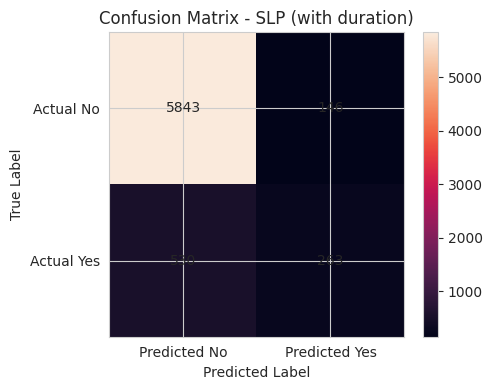

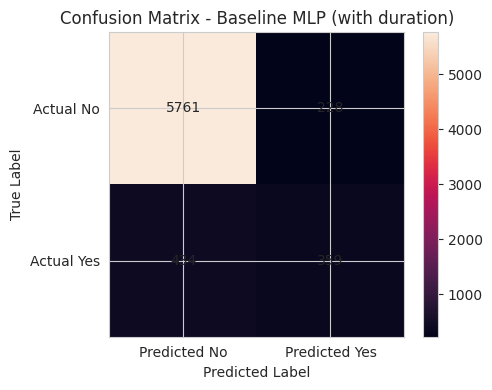

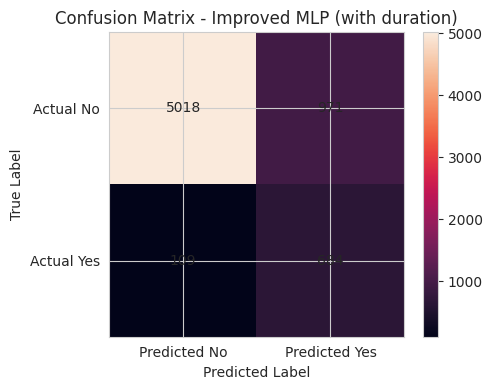

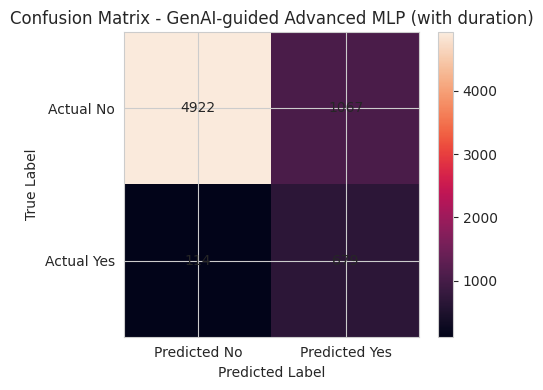


Classification Report - SLP (with duration)
              precision    recall  f1-score   support

          no       0.92      0.98      0.95      5989
         yes       0.64      0.33      0.44       793

    accuracy                           0.90      6782
   macro avg       0.78      0.65      0.69      6782
weighted avg       0.88      0.90      0.89      6782


Classification Report - Baseline MLP (with duration)
              precision    recall  f1-score   support

          no       0.93      0.96      0.95      5989
         yes       0.61      0.45      0.52       793

    accuracy                           0.90      6782
   macro avg       0.77      0.71      0.73      6782
weighted avg       0.89      0.90      0.90      6782


Classification Report - Improved MLP (with duration)
              precision    recall  f1-score   support

          no       0.98      0.84      0.90      5989
         yes       0.41      0.86      0.56       793

    accuracy                 

In [178]:


# Section 13 - Confusion matrix analysis for all neural models


# What this cell does:
# This cell builds confusion matrices for all four models,
# plots them one by one, and creates a clean summary table
# that we can reuse later in the final comparison.

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, classification_report


# Step 1: Safety checks
# Make sure the prediction dictionaries from Section 12 exist.

required_variables = [
    "test_prediction_dict",
    "y_test_wd_np"
]

missing_variables = [var for var in required_variables if var not in globals()]

if missing_variables:
    raise ValueError(
        f"These variables are missing: {missing_variables}. "
        "Please run Section 12 first."
    )

print("Prediction outputs from Section 12 are available.")


# Step 2: Build confusion matrix summary rows

cm_summary_rows = []

for model_name, y_pred in test_prediction_dict.items():
    cm = confusion_matrix(y_test_wd_np, y_pred)
    tn, fp, fn, tp = cm.ravel()

    cm_summary_rows.append({
        "Model": model_name,
        "TN": tn,
        "FP": fp,
        "FN": fn,
        "TP": tp
    })

# Create summary table
cm_summary_df = pd.DataFrame(cm_summary_rows)

print("\nConfusion matrix summary table:")
display(cm_summary_df)


# Step 3: Plot confusion matrix for each model
# This keeps each figure separate and easy to read.

for model_name, y_pred in test_prediction_dict.items():
    cm = confusion_matrix(y_test_wd_np, y_pred)

    plt.figure(figsize=(5, 4))
    plt.imshow(cm, interpolation="nearest", aspect="auto")
    plt.title(f"Confusion Matrix - {model_name}")
    plt.colorbar()
    plt.xticks([0, 1], ["Predicted No", "Predicted Yes"])
    plt.yticks([0, 1], ["Actual No", "Actual Yes"])

    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            plt.text(j, i, cm[i, j], ha="center", va="center")

    plt.xlabel("Predicted Label")
    plt.ylabel("True Label")
    plt.tight_layout()
    plt.show()


# Step 4: Print classification reports
# This gives class-wise precision, recall, and F1-score.

for model_name, y_pred in test_prediction_dict.items():
    print("\n" + "=" * 70)
    print(f"Classification Report - {model_name}")
    print("=" * 70)
    print(classification_report(
        y_test_wd_np,
        y_pred,
        target_names=["no", "yes"],
        zero_division=0
    ))

# Section 14: Ambiguity and Uncertainty Analysis of Neural Models

In addition to standard evaluation metrics, I also analyse prediction uncertainty to identify ambiguous or difficult-to-classify samples. This is important because the coursework requires the model not only to classify cases, but also to highlight uncertainty in an interpretable way.

For this project, ambiguity is measured using the predicted probability of the positive class. Predictions close to 0.5 indicate that the model is less certain, because it sees the case as being close to the decision boundary between “no” and “yes”. Following the approach suggested in Part B, I define an ambiguity band from 0.40 to 0.60. Predictions inside this interval are treated as ambiguous.

This analysis helps answer three questions:
- how many samples each model considers ambiguous,
- how accurate each model is on ambiguous samples,
- and whether the models are more reliable on confident predictions than on uncertain ones.

Using this method keeps the uncertainty analysis simple, interpretable, and directly linked to the probability outputs of the ANN models.

Probability and prediction outputs are available.
Ambiguity band: 0.4 to 0.6

Ambiguity / uncertainty summary:


,Model,Ambiguous %,Accuracy on Ambiguous Samples,Accuracy on Confident Samples
0,Baseline MLP (with duration),7.1955,0.5430,0.9303
1,GenAI-guided Advanced MLP (with duration),6.5615,0.4742,0.8506
2,Improved MLP (with duration),5.7800,0.5128,0.8609
3,SLP (with duration),2.9047,0.4569,0.9136


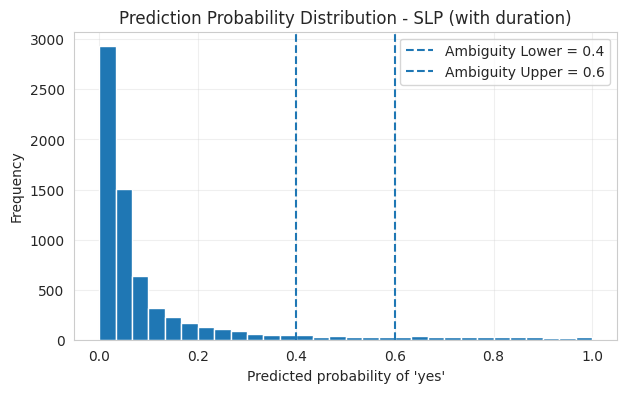

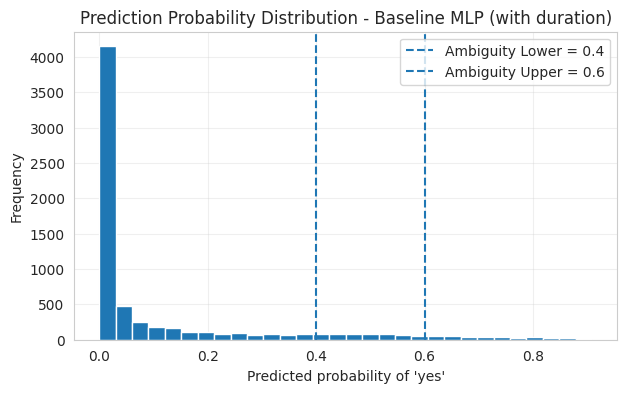

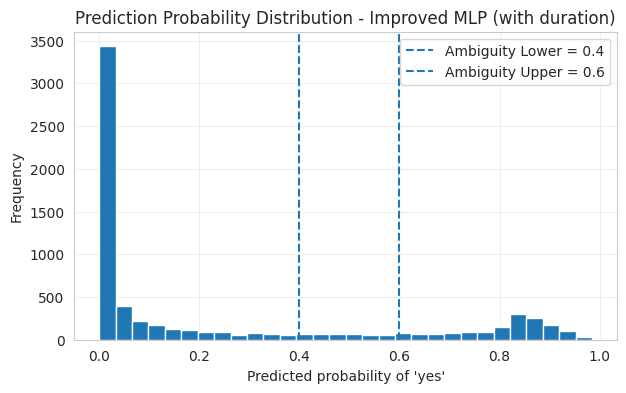

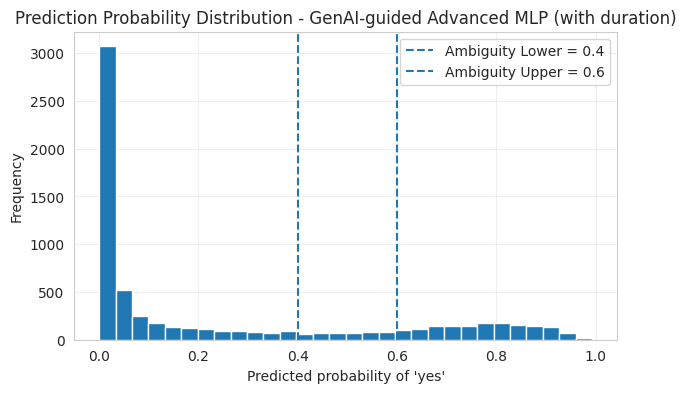


Most ambiguous predictions - SLP (with duration)


,y_true,y_pred,prob_yes,correct,uncertainty_distance,is_ambiguous
4241,1,0,0.499961,0,0.000039,1
5689,1,0,0.498850,0,0.001150,1
4480,0,1,0.501845,0,0.001845,1
2360,1,0,0.497690,0,0.002310,1
2463,1,0,0.497284,0,0.002716,1
5536,0,0,0.497068,1,0.002932,1
2898,1,1,0.503125,1,0.003125,1
5114,0,1,0.503266,0,0.003266,1
5583,0,1,0.505606,0,0.005606,1
6209,1,0,0.494374,0,0.005626,1



Most ambiguous predictions - Baseline MLP (with duration)


,y_true,y_pred,prob_yes,correct,uncertainty_distance,is_ambiguous
3300,1,1,0.500204,1,0.000204,1
101,0,1,0.500246,0,0.000246,1
4130,0,1,0.500306,0,0.000306,1
1542,1,1,0.500373,1,0.000373,1
4299,0,1,0.500569,0,0.000569,1
2134,1,1,0.500573,1,0.000573,1
375,0,0,0.499349,1,0.000651,1
5428,0,1,0.500673,0,0.000673,1
4591,0,0,0.498341,1,0.001659,1
3236,0,0,0.498317,1,0.001683,1



Most ambiguous predictions - Improved MLP (with duration)


,y_true,y_pred,prob_yes,correct,uncertainty_distance,is_ambiguous
759,0,1,0.500101,0,0.000101,1
390,0,1,0.500275,0,0.000275,1
5777,0,0,0.499495,1,0.000505,1
4543,0,0,0.499245,1,0.000755,1
1469,1,0,0.499177,0,0.000823,1
2909,0,0,0.499107,1,0.000893,1
6088,1,1,0.501660,1,0.001660,1
6117,1,1,0.501756,1,0.001756,1
2771,0,0,0.497862,1,0.002138,1
5390,0,1,0.502242,0,0.002242,1



Most ambiguous predictions - GenAI-guided Advanced MLP (with duration)


,y_true,y_pred,prob_yes,correct,uncertainty_distance,is_ambiguous
2914,1,0,0.499994,0,0.000006,1
1241,0,1,0.500149,0,0.000149,1
5426,0,0,0.499350,1,0.000650,1
4881,0,1,0.500948,0,0.000948,1
1201,0,0,0.498845,1,0.001155,1
4203,0,1,0.501326,0,0.001326,1
5864,0,1,0.501361,0,0.001361,1
288,0,1,0.501394,0,0.001394,1
3732,0,0,0.498590,1,0.001410,1
5312,0,0,0.498543,1,0.001457,1


In [179]:

# Section 14 - Ambiguity / uncertainty analysis for all models


# What this cell does:
# This cell checks how uncertain each model is by looking at
# predicted probabilities close to 0.5.
# It creates a summary table and also shows probability plots.
# so we can compare confidence behaviour across models.

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


# Step 1: Safety checks
# Make sure the probability and prediction outputs from
# Section 12 are available.

required_variables = [
    "test_probability_dict",
    "test_prediction_dict",
    "y_test_wd_np"
]

missing_variables = [var for var in required_variables if var not in globals()]

if missing_variables:
    raise ValueError(
        f"These variables are missing: {missing_variables}. "
        "Please run Section 12 first."
    )

print("Probability and prediction outputs are available.")


# Step 2: Define ambiguity band
# Predictions inside this interval are treated as uncertain.

ambiguity_lower = 0.40
ambiguity_upper = 0.60

print(f"Ambiguity band: {ambiguity_lower} to {ambiguity_upper}")


# Step 3: Build ambiguity summary for each model

uncertainty_summary_rows = []
uncertainty_detail_dict = {}

for model_name in test_probability_dict.keys():
    y_prob = test_probability_dict[model_name]
    y_pred = test_prediction_dict[model_name]

    uncertainty_df = pd.DataFrame({
        "y_true": y_test_wd_np.astype(int),
        "y_pred": y_pred.astype(int),
        "prob_yes": y_prob
    })

    uncertainty_df["correct"] = (uncertainty_df["y_true"] == uncertainty_df["y_pred"]).astype(int)
    uncertainty_df["uncertainty_distance"] = np.abs(uncertainty_df["prob_yes"] - 0.5)
    uncertainty_df["is_ambiguous"] = (
        (uncertainty_df["prob_yes"] >= ambiguity_lower) &
        (uncertainty_df["prob_yes"] <= ambiguity_upper)
    ).astype(int)

    ambiguous_pct = 100 * uncertainty_df["is_ambiguous"].mean()

    if uncertainty_df["is_ambiguous"].sum() > 0:
        ambiguous_acc = uncertainty_df.loc[
            uncertainty_df["is_ambiguous"] == 1, "correct"
        ].mean()
    else:
        ambiguous_acc = np.nan

    if uncertainty_df["is_ambiguous"].sum() < len(uncertainty_df):
        confident_acc = uncertainty_df.loc[
            uncertainty_df["is_ambiguous"] == 0, "correct"
        ].mean()
    else:
        confident_acc = np.nan

    uncertainty_summary_rows.append({
        "Model": model_name,
        "Ambiguous %": ambiguous_pct,
        "Accuracy on Ambiguous Samples": ambiguous_acc,
        "Accuracy on Confident Samples": confident_acc
    })

    uncertainty_detail_dict[model_name] = uncertainty_df

# Final ambiguity summary table
uncertainty_summary_df = pd.DataFrame(uncertainty_summary_rows)

numeric_cols = uncertainty_summary_df.select_dtypes(include=[np.number]).columns
uncertainty_summary_df[numeric_cols] = uncertainty_summary_df[numeric_cols].round(4)

print("\nAmbiguity / uncertainty summary:")
display(uncertainty_summary_df.sort_values(by="Ambiguous %", ascending=False).reset_index(drop=True))


# Step 4: Plot probability distributions for each model

for model_name, y_prob in test_probability_dict.items():
    plt.figure(figsize=(7, 4))
    plt.hist(y_prob, bins=30)
    plt.axvline(ambiguity_lower, linestyle="--", label=f"Ambiguity Lower = {ambiguity_lower}")
    plt.axvline(ambiguity_upper, linestyle="--", label=f"Ambiguity Upper = {ambiguity_upper}")
    plt.title(f"Prediction Probability Distribution - {model_name}")
    plt.xlabel("Predicted probability of 'yes'")
    plt.ylabel("Frequency")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()


# Step 5: Show the most ambiguous cases for each model

for model_name, uncertainty_df in uncertainty_detail_dict.items():
    print("\n" + "=" * 75)
    print(f"Most ambiguous predictions - {model_name}")
    print("=" * 75)

    most_ambiguous_cases = uncertainty_df.iloc[
        np.argsort(np.abs(uncertainty_df["prob_yes"] - 0.5))
    ].head(10)

    display(most_ambiguous_cases)

# Section 15: Final Comparison of Part A and Part B Models

This section combines the main results from the test-set evaluation, confusion matrix analysis, and ambiguity analysis in order to identify the strongest model overall.

The final comparison is not based on accuracy alone. Since the Bank Marketing dataset is imbalanced, the most important criteria are the model’s ability to detect the minority “yes” class while still maintaining reasonable overall reliability. For this reason, I focus especially on:
- recall for the “yes” class,
- F1-score,
- balanced accuracy,
- ROC-AUC and PR-AUC,
- false positives and false negatives,
- and behaviour on ambiguous versus confident predictions.

This combined comparison is also important for Part B because it allows the GenAI-guided model to be judged directly against the independently developed models from Part A. The purpose is not to assume that the AI-supported model will automatically perform better, but to test whether the guidance actually led to a stronger final outcome under the same evaluation procedure. This directly supports the coursework requirement to critically reflect on how Generative AI influenced the modelling process and outcomes. :contentReference[oaicite:0]{index=0}

In [180]:

# Section 15 - Final comparison of Part A and Part B models


# What this cell does:
# This cell combines the main test metrics and the ambiguity
# results into one final summary table. It also creates a few
# ranking views so we can clearly identify which model performs
# best depending on the metric we care about most.

import numpy as np
import pandas as pd


# Step 1: Safety checks
# Make sure the earlier result tables already exist.

required_variables = [
    "test_results_neural_models",
    "uncertainty_summary_df"
]

missing_variables = [var for var in required_variables if var not in globals()]

if missing_variables:
    raise ValueError(
        f"These variables are missing: {missing_variables}. "
        "Please run Sections 12 and 14 first."
    )

print("All required comparison tables are available.")


# Step 2: Merge the test metrics and ambiguity summary
# This gives us one master comparison table.

final_model_comparison_df = test_results_neural_models.merge(
    uncertainty_summary_df,
    on="Model",
    how="left"
)


# Step 3: Add ranking columns
# Lower rank number = better performance on that metric.
# For FP and FN, lower is better.

final_model_comparison_df["Rank_Accuracy"] = final_model_comparison_df["Accuracy"].rank(ascending=False, method="min")
final_model_comparison_df["Rank_Recall"] = final_model_comparison_df["Recall"].rank(ascending=False, method="min")
final_model_comparison_df["Rank_F1"] = final_model_comparison_df["F1-Score"].rank(ascending=False, method="min")
final_model_comparison_df["Rank_Balanced_Accuracy"] = final_model_comparison_df["Balanced Accuracy"].rank(ascending=False, method="min")
final_model_comparison_df["Rank_ROC_AUC"] = final_model_comparison_df["ROC-AUC"].rank(ascending=False, method="min")
final_model_comparison_df["Rank_PR_AUC"] = final_model_comparison_df["PR-AUC"].rank(ascending=False, method="min")
final_model_comparison_df["Rank_FP"] = final_model_comparison_df["FP"].rank(ascending=True, method="min")
final_model_comparison_df["Rank_FN"] = final_model_comparison_df["FN"].rank(ascending=True, method="min")

# Optional overall rank score:
# This is not the only basis for judgement, but it gives a simple summary.
final_model_comparison_df["Average_Rank"] = final_model_comparison_df[
    [
        "Rank_Accuracy",
        "Rank_Recall",
        "Rank_F1",
        "Rank_Balanced_Accuracy",
        "Rank_ROC_AUC",
        "Rank_PR_AUC",
        "Rank_FP",
        "Rank_FN"
    ]
].mean(axis=1)


# Step 4: Round numeric columns for cleaner display

numeric_cols = final_model_comparison_df.select_dtypes(include=[np.number]).columns
final_model_comparison_df[numeric_cols] = final_model_comparison_df[numeric_cols].round(4)


# Step 5: Display the full final comparison table

print("\nFinal combined comparison table:")
display(final_model_comparison_df.sort_values(by="F1-Score", ascending=False).reset_index(drop=True))


# Step 6: Show key winners

best_by_accuracy = final_model_comparison_df.sort_values(by="Accuracy", ascending=False).head(1)
best_by_recall = final_model_comparison_df.sort_values(by="Recall", ascending=False).head(1)
best_by_f1 = final_model_comparison_df.sort_values(by="F1-Score", ascending=False).head(1)
best_by_balanced_acc = final_model_comparison_df.sort_values(by="Balanced Accuracy", ascending=False).head(1)
best_by_roc_auc = final_model_comparison_df.sort_values(by="ROC-AUC", ascending=False).head(1)
best_by_pr_auc = final_model_comparison_df.sort_values(by="PR-AUC", ascending=False).head(1)
best_by_average_rank = final_model_comparison_df.sort_values(by="Average_Rank", ascending=True).head(1)

print("\nBest model by Accuracy:")
display(best_by_accuracy)

print("\nBest model by Recall:")
display(best_by_recall)

print("\nBest model by F1-Score:")
display(best_by_f1)

print("\nBest model by Balanced Accuracy:")
display(best_by_balanced_acc)

print("\nBest model by ROC-AUC:")
display(best_by_roc_auc)

print("\nBest model by PR-AUC:")
display(best_by_pr_auc)

print("\nBest model by Average Rank:")
display(best_by_average_rank)

All required comparison tables are available.

Final combined comparison table:


,Model,Accuracy,Precision,Recall,F1-Score,Balanced Accuracy,ROC-AUC,PR-AUC,FP,FN,...,Accuracy on Confident Samples,Rank_Accuracy,Rank_Recall,Rank_F1,Rank_Balanced_Accuracy,Rank_ROC_AUC,Rank_PR_AUC,Rank_FP,Rank_FN,Average_Rank
0,Improved MLP (with duration),0.8408,0.4133,0.8625,0.5588,0.8502,0.9215,0.5947,971,109,...,0.8609,3.0,1.0,1.0,1.0,1.0,1.0,3.0,1.0,1.500
1,GenAI-guided Advanced MLP (with duration),0.8259,0.3889,0.8562,0.5349,0.8390,0.9137,0.5578,1067,114,...,0.8506,4.0,2.0,2.0,2.0,3.0,3.0,4.0,2.0,2.750
2,Baseline MLP (with duration),0.9024,0.6116,0.4527,0.5203,0.7073,0.9188,0.5737,228,434,...,0.9303,1.0,3.0,3.0,3.0,2.0,2.0,2.0,3.0,2.375
3,SLP (with duration),0.9003,0.6430,0.3317,0.4376,0.6536,0.9036,0.5343,146,530,...,0.9136,2.0,4.0,4.0,4.0,4.0,4.0,1.0,4.0,3.375



Best model by Accuracy:


,Model,Accuracy,Precision,Recall,F1-Score,Balanced Accuracy,ROC-AUC,PR-AUC,FP,FN,...,Accuracy on Confident Samples,Rank_Accuracy,Rank_Recall,Rank_F1,Rank_Balanced_Accuracy,Rank_ROC_AUC,Rank_PR_AUC,Rank_FP,Rank_FN,Average_Rank
1,Baseline MLP (with duration),0.9024,0.6116,0.4527,0.5203,0.7073,0.9188,0.5737,228,434,...,0.9303,1.0,3.0,3.0,3.0,2.0,2.0,2.0,3.0,2.375



Best model by Recall:


...

,Model,Accuracy,Precision,Recall,F1-Score,Balanced Accuracy,ROC-AUC,PR-AUC,FP,FN,...,Accuracy on Confident Samples,Rank_Accuracy,Rank_Recall,Rank_F1,Rank_Balanced_Accuracy,Rank_ROC_AUC,Rank_PR_AUC,Rank_FP,Rank_FN,Average_Rank
2,Improved MLP (with duration),0.8408,0.4133,0.8625,0.5588,0.8502,0.9215,0.5947,971,109,...,0.8609,3.0,1.0,1.0,1.0,1.0,1.0,3.0,1.0,1.5



Best model by PR-AUC:


,Model,Accuracy,Precision,Recall,F1-Score,Balanced Accuracy,ROC-AUC,PR-AUC,FP,FN,...,Accuracy on Confident Samples,Rank_Accuracy,Rank_Recall,Rank_F1,Rank_Balanced_Accuracy,Rank_ROC_AUC,Rank_PR_AUC,Rank_FP,Rank_FN,Average_Rank
2,Improved MLP (with duration),0.8408,0.4133,0.8625,0.5588,0.8502,0.9215,0.5947,971,109,...,0.8609,3.0,1.0,1.0,1.0,1.0,1.0,3.0,1.0,1.5



Best model by Average Rank:


,Model,Accuracy,Precision,Recall,F1-Score,Balanced Accuracy,ROC-AUC,PR-AUC,FP,FN,...,Accuracy on Confident Samples,Rank_Accuracy,Rank_Recall,Rank_F1,Rank_Balanced_Accuracy,Rank_ROC_AUC,Rank_PR_AUC,Rank_FP,Rank_FN,Average_Rank
2,Improved MLP (with duration),0.8408,0.4133,0.8625,0.5588,0.8502,0.9215,0.5947,971,109,...,0.8609,3.0,1.0,1.0,1.0,1.0,1.0,3.0,1.0,1.5


# Section 16: Graphical Comparison of Models

To make the final comparison easier to interpret, I visualise the main results across all four neural models. These graphs help show the trade-offs more clearly than tables alone, especially the differences between overall accuracy, minority-class detection, false positives, and uncertainty behaviour.

The visual comparison focuses on:
- standard performance metrics such as accuracy, recall, F1-score, balanced accuracy, ROC-AUC, and PR-AUC,
- error behaviour through false positives and false negatives,
- and ambiguity behaviour through the percentage of ambiguous predictions and the difference between ambiguous and confident accuracy.

These graphs support the written comparison by making it easier to see which model is strongest overall and where the GenAI-guided model differs from the independently developed Part A models.

Final comparison table found. Creating improved graph layout...


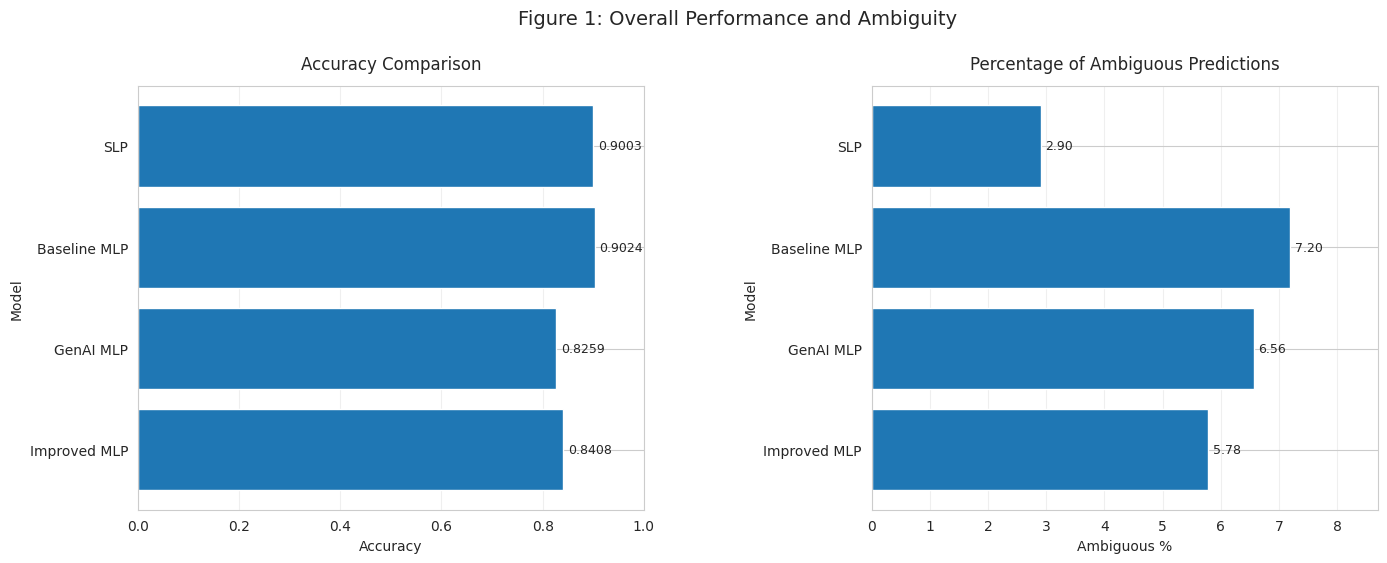

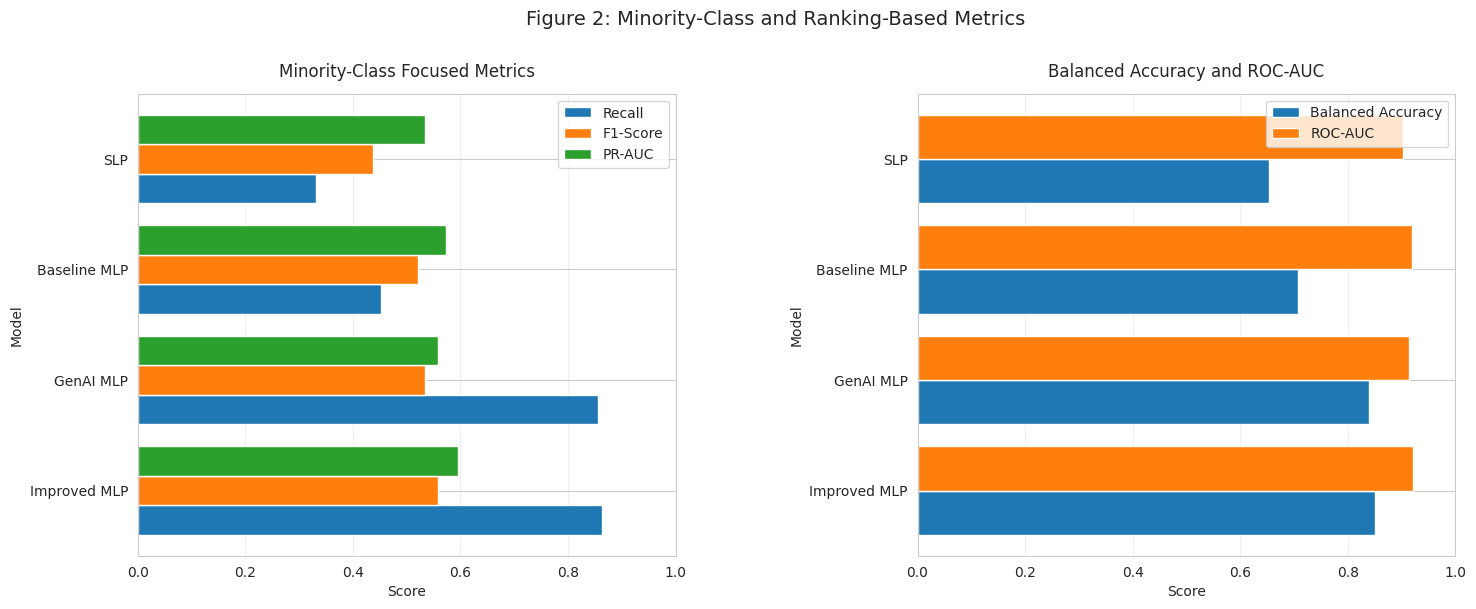

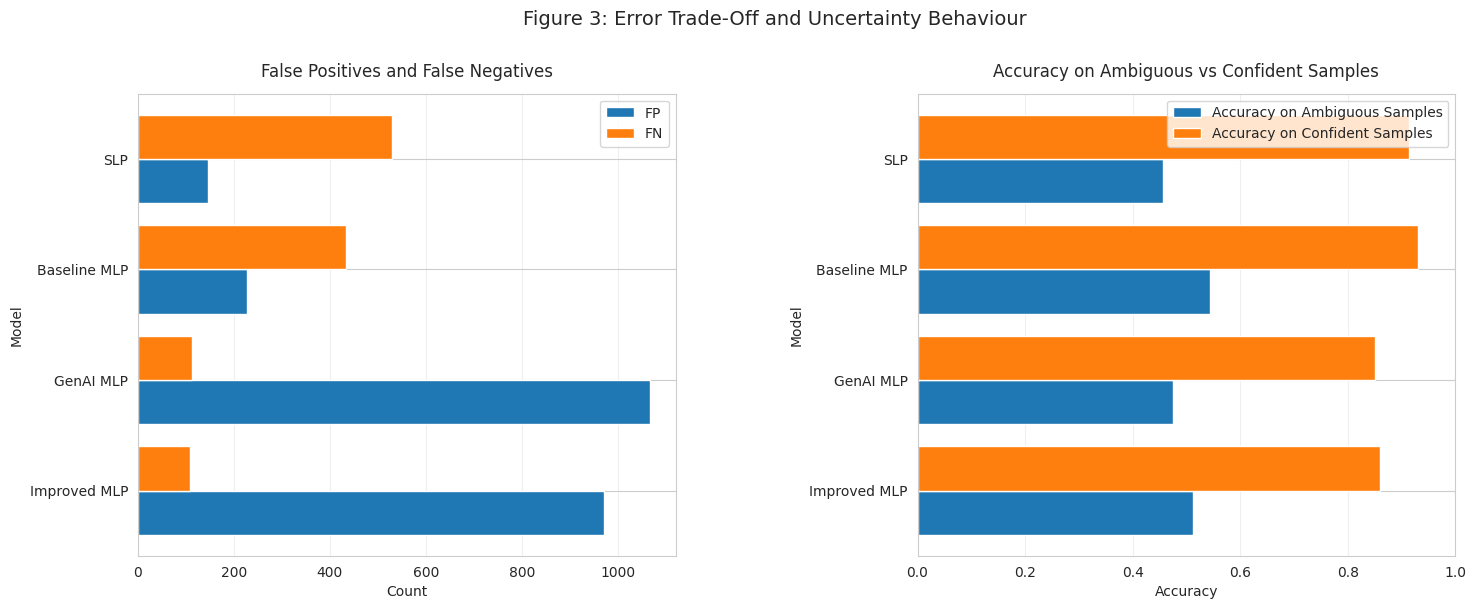

In [181]:

# Section 16 - Graphical comparison of all neural models


# What this cell does:
# This cell creates a cleaner final comparison section using
# multiple well-spaced subplot layouts instead of one plot at a time.
# The aim is to make the graphs easier to read in Colab.

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


# Step 1: Safety check

if "final_model_comparison_df" not in globals():
    raise ValueError("final_model_comparison_df is missing. Please run Section 15 first.")

print("Final comparison table found. Creating improved graph layout...")


# Step 2: Prepare plotting dataframe

plot_df = final_model_comparison_df.copy()

model_name_map = {
    "SLP (with duration)": "SLP",
    "Baseline MLP (with duration)": "Baseline MLP",
    "Improved MLP (with duration)": "Improved MLP",
    "GenAI-guided Advanced MLP (with duration)": "GenAI MLP"
}

plot_df["Model Short"] = plot_df["Model"].map(model_name_map)

# Sort by F1-score so strongest overall model appears first
plot_df = plot_df.sort_values(by="F1-Score", ascending=False).reset_index(drop=True)


# Step 3: Small helper functions

def add_value_labels_barh(ax, fmt="{:.3f}", offset=0.01):
    for bar in ax.patches:
        width = bar.get_width()
        y = bar.get_y() + bar.get_height() / 2
        ax.text(width + offset, y, fmt.format(width), va="center", fontsize=9)

def make_barh(ax, df, value_col, title, xlabel, xlim=None, fmt="{:.3f}", offset=0.01):
    ax.barh(df["Model Short"], df[value_col])
    ax.set_title(title, pad=12)
    ax.set_xlabel(xlabel)
    ax.set_ylabel("Model")
    if xlim is not None:
        ax.set_xlim(xlim)
    ax.grid(True, axis="x", alpha=0.3)
    add_value_labels_barh(ax, fmt=fmt, offset=offset)

def make_grouped_barh(ax, df, metrics, title, xlabel, xlim=None):
    y = np.arange(len(df))
    n = len(metrics)
    height = 0.8 / n

    for i, metric in enumerate(metrics):
        ax.barh(
            y + (i - (n - 1) / 2) * height,
            df[metric],
            height=height,
            label=metric
        )

    ax.set_yticks(y)
    ax.set_yticklabels(df["Model Short"])
    ax.set_title(title, pad=12)
    ax.set_xlabel(xlabel)
    ax.set_ylabel("Model")
    if xlim is not None:
        ax.set_xlim(xlim)
    ax.grid(True, axis="x", alpha=0.3)
    ax.legend(frameon=True)


# Figure 1: Accuracy + Ambiguous %

fig, axes = plt.subplots(1, 2, figsize=(16, 5.5))
fig.suptitle("Figure 1: Overall Performance and Ambiguity", fontsize=14, y=1.02)

make_barh(
    ax=axes[0],
    df=plot_df,
    value_col="Accuracy",
    title="Accuracy Comparison",
    xlabel="Accuracy",
    xlim=(0, 1.0),
    fmt="{:.4f}",
    offset=0.01
)

make_barh(
    ax=axes[1],
    df=plot_df,
    value_col="Ambiguous %",
    title="Percentage of Ambiguous Predictions",
    xlabel="Ambiguous %",
    xlim=(0, max(plot_df["Ambiguous %"]) + 1.5),
    fmt="{:.2f}",
    offset=0.08
)

plt.subplots_adjust(wspace=0.45, hspace=0.35)
plt.show()


# Figure 2: Minority-class metrics + ranking metrics

fig, axes = plt.subplots(1, 2, figsize=(17, 6))
fig.suptitle("Figure 2: Minority-Class and Ranking-Based Metrics", fontsize=14, y=1.02)

make_grouped_barh(
    ax=axes[0],
    df=plot_df,
    metrics=["Recall", "F1-Score", "PR-AUC"],
    title="Minority-Class Focused Metrics",
    xlabel="Score",
    xlim=(0, 1.0)
)

make_grouped_barh(
    ax=axes[1],
    df=plot_df,
    metrics=["Balanced Accuracy", "ROC-AUC"],
    title="Balanced Accuracy and ROC-AUC",
    xlabel="Score",
    xlim=(0, 1.0)
)

plt.subplots_adjust(wspace=0.45, hspace=0.35)
plt.show()


# Figure 3: Error trade-off + uncertainty accuracy

fig, axes = plt.subplots(1, 2, figsize=(17, 6))
fig.suptitle("Figure 3: Error Trade-Off and Uncertainty Behaviour", fontsize=14, y=1.02)

make_grouped_barh(
    ax=axes[0],
    df=plot_df,
    metrics=["FP", "FN"],
    title="False Positives and False Negatives",
    xlabel="Count"
)

make_grouped_barh(
    ax=axes[1],
    df=plot_df,
    metrics=["Accuracy on Ambiguous Samples", "Accuracy on Confident Samples"],
    title="Accuracy on Ambiguous vs Confident Samples",
    xlabel="Accuracy",
    xlim=(0, 1.0)
)

plt.subplots_adjust(wspace=0.45, hspace=0.35)
plt.show()

## Interpretation of the Graphical Comparison

The improved graph layout makes the trade-offs clearer. The **Baseline MLP** has the highest overall accuracy, but the **Improved MLP** remains the strongest model on the more important minority-class measures, including recall, F1-score, balanced accuracy, ROC-AUC, and PR-AUC.

The **GenAI MLP** is competitive and follows a similar high-recall pattern, but it produces more false positives and does not exceed the performance of the Improved MLP. The ambiguity plots also confirm that all models perform much more better on confident predictions than on ambiguous ones.

Overall, the visual comparison supports the same conclusion as the numerical analysis: the **Improved MLP** is the best final model, while the **GenAI-guided model** is useful but not superior.

# Section 17: Critical Reflection on Generative AI Support

Part B showed that Generative AI was useful as a support tool, but it did not automatically produce the best final model. The AI guidance helped generate a plausible advanced ANN architecture and suggested sensible ideas such as dropout, batch normalization, class weighting, early stopping, broader evaluation metrics, and probability-based ambiguity analysis. These suggestions were helpful because they expanded the range of modelling options and made the development process more structured.

However, the results also showed that AI-generated guidance still needed critical checking. The GenAI-guided Advanced MLP produced a competitive model, especially in terms of recall for the minority “yes” class, but it did not outperform the strongest independently developed model from Part A. In the final comparison, the improved MLP achieved better F1-score, balanced accuracy, ROC-AUC, PR-AUC, and overall ranking, while the GenAI-guided model produced more false positives and weaker ambiguity performance. This means that although the AI suggestions were useful, they were not automatically optimal for this dataset.

An important lesson from Part B is that Generative AI works best as a guidance tool rather than a replacement for modelling decisions. Some suggestions were clearly appropriate and were adopted, while others had to be rejected. For example, ideas such as using CNNs, RNNs, or overly deep architectures would not have suited this tabular binary classification problem and would have reduced the fairness of comparison with Part A. This highlights that AI outputs must always be filtered through dataset knowledge, coursework requirements, and critical judgement.

Overall, Part B demonstrates that Generative AI can support the modelling process by helping generate, organise, and justify model design ideas. At the same time, the final quality of the model still depended on testing, comparison, and human decision-making. In this project, the independently developed Improved MLP remained the best model, which shows that critical thinking was more important than simply following AI suggestions.

In [182]:

# Final Section - Save all Part B outputs cleanly


# What this cell does:
# This cell saves all important Part B outputs, including:
# - the GenAI-guided model
# - key result tables
# - prompt/adoption documentation tables
# - ambiguous case tables
# - final comparison graphs

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


# Step 1: Choose save location
# If Google Drive is mounted, save there.
# Otherwise, save locally in the notebook session.

if os.path.exists("/content/drive/MyDrive"):
    base_output_dir = "/content/drive/MyDrive/bank_marketing_part_b_outputs"
else:
    base_output_dir = "bank_marketing_part_b_outputs"

models_dir = os.path.join(base_output_dir, "models")
tables_dir = os.path.join(base_output_dir, "tables")
figures_dir = os.path.join(base_output_dir, "figures")

os.makedirs(models_dir, exist_ok=True)
os.makedirs(tables_dir, exist_ok=True)
os.makedirs(figures_dir, exist_ok=True)

print("Saving Part B outputs to:")
print(base_output_dir)


# Step 2: Safety checks

required_variables = [
    "genai_mlp_wd",
    "history_genai_df",
    "genai_val_summary",
    "test_results_neural_models",
    "cm_summary_df",
    "uncertainty_summary_df",
    "final_model_comparison_df"
]

missing_variables = [var for var in required_variables if var not in globals()]

if missing_variables:
    raise ValueError(
        f"These variables are missing: {missing_variables}. "
        "Please run all Part B sections first."
    )


# Step 3: Save the Part B model

genai_model_path = os.path.join(models_dir, "genai_guided_advanced_mlp.keras")
genai_mlp_wd.save(genai_model_path)
print(f"\nSaved model: {genai_model_path}")


# Step 4: Save main result tables

history_genai_df.to_csv(os.path.join(tables_dir, "genai_training_history.csv"), index=False)
genai_val_summary.to_csv(os.path.join(tables_dir, "genai_validation_summary.csv"), index=False)
test_results_neural_models.to_csv(os.path.join(tables_dir, "all_models_test_results.csv"), index=False)
cm_summary_df.to_csv(os.path.join(tables_dir, "confusion_matrix_summary.csv"), index=False)
uncertainty_summary_df.to_csv(os.path.join(tables_dir, "uncertainty_summary.csv"), index=False)
final_model_comparison_df.to_csv(os.path.join(tables_dir, "final_model_comparison.csv"), index=False)

print("\nSaved main result tables.")


# Step 5: Save Part B documentation tables
# These match the written Part B sections.

prompt_log_save_df = pd.DataFrame({
    "Prompt Number": ["Prompt 1", "Prompt 2", "Prompt 3", "Prompt 4", "Prompt 5"],
    "Focus Area": [
        "ANN architecture design",
        "Hyperparameter tuning",
        "Evaluation metrics",
        "Ambiguity / uncertainty analysis",
        "Critical checking of AI suggestions"
    ],
    "Prompt Used": [
        """I am working on the UCI Bank Marketing dataset for a binary classification ANN coursework project. The dataset is tabular, the target variable is imbalanced, and I have already built: 1) a single-layer perceptron (SLP) 2) a baseline MLP 3) an improved MLP with dropout and class weights. Suggest one stronger feedforward ANN architecture for Part B using the same preprocessed tabular inputs. Please justify: number of hidden layers, number of neurons, activation functions, dropout, whether batch normalization should be used, and why this architecture may be suitable for imbalanced tabular binary classification.""",

        """For a binary classification ANN on the UCI Bank Marketing dataset with class imbalance, suggest realistic hyperparameter settings for learning rate, batch size, epochs, early stopping, ReduceLROnPlateau, dropout levels, and class weights. I want settings appropriate for a coursework project and suitable for comparison against simpler ANN baselines.""",

        """I am evaluating ANN models on an imbalanced binary classification problem using the Bank Marketing dataset. Beyond accuracy, which evaluation metrics should I use and why? Please include precision, recall, F1-score, balanced accuracy, ROC-AUC, PR-AUC, confusion matrix analysis, and how to interpret a model with lower accuracy but higher recall and F1-score.""",

        """For a binary ANN classifier with sigmoid output probabilities, suggest simple and interpretable ways to identify ambiguous or uncertain predictions. I want techniques suitable for coursework, not advanced research-only methods. Please explain how predictions close to 0.5, fixed ambiguity bands such as 0.40 to 0.60, and confidence-based error inspection can be used.""",

        """I do not want to blindly copy AI suggestions. For tabular binary classification using an ANN, which suggested ideas should be critically checked or possibly rejected, and why?"""
    ]
})

ai_review_save_df = pd.DataFrame({
    "Suggestion": [
        "Use a deeper feedforward MLP",
        "Add dropout regularisation",
        "Use batch normalization",
        "Use class weights",
        "Use early stopping",
        "Use ReduceLROnPlateau",
        "Use multiple evaluation metrics beyond accuracy",
        "Use probability-based ambiguity analysis",
        "Use CNN architecture",
        "Use RNN or LSTM architecture",
        "Use a very deep ANN with many hidden layers",
        "Change the preprocessing pipeline completely"
    ],
    "Decision": [
        "Adopted",
        "Adopted",
        "Adopted",
        "Adopted",
        "Adopted",
        "Adopted",
        "Adopted",
        "Adopted",
        "Rejected",
        "Rejected",
        "Rejected",
        "Rejected"
    ],
    "Reason": [
        "More advanced than earlier baselines while still suitable for tabular data.",
        "Helps reduce overfitting and improve generalisation.",
        "Can stabilise training in deeper feedforward networks.",
        "Addresses class imbalance in the minority 'yes' class.",
        "Prevents unnecessary training once validation performance stops improving.",
        "Allows learning rate reduction when validation loss plateaus.",
        "Needed because accuracy alone is not enough for imbalanced classification.",
        "Supports coursework requirement to identify ambiguous predictions.",
        "Not suitable because the dataset is tabular rather than image-based.",
        "Not suitable because the dataset is not sequential time-series data.",
        "Too complex for this coursework dataset and more likely to overfit.",
        "Would reduce fairness of comparison with Part A."
    ]
})

prompt_log_save_df.to_csv(os.path.join(tables_dir, "part_b_prompt_log.csv"), index=False)
ai_review_save_df.to_csv(os.path.join(tables_dir, "part_b_adopted_rejected_suggestions.csv"), index=False)

print("Saved prompt and AI suggestion review tables.")


# Step 6: Save most ambiguous cases for each model

if "uncertainty_detail_dict" in globals():
    for model_name, df in uncertainty_detail_dict.items():
        safe_name = (
            model_name.lower()
            .replace(" ", "_")
            .replace("(", "")
            .replace(")", "")
            .replace("-", "_")
        )
        most_ambiguous = df.iloc[
            np.argsort(np.abs(df["prob_yes"] - 0.5))
        ].head(20)

        most_ambiguous.to_csv(
            os.path.join(tables_dir, f"most_ambiguous_{safe_name}.csv"),
            index=False
        )
    print("Saved ambiguous-case tables for each model.")
else:
    print("uncertainty_detail_dict not found, so ambiguous-case CSVs were skipped.")


# Step 7: Recreate and save Section 16 graphs

plot_df = final_model_comparison_df.copy()

model_name_map = {
    "SLP (with duration)": "SLP",
    "Baseline MLP (with duration)": "Baseline MLP",
    "Improved MLP (with duration)": "Improved MLP",
    "GenAI-guided Advanced MLP (with duration)": "GenAI MLP"
}

plot_df["Model Short"] = plot_df["Model"].map(model_name_map)
plot_df = plot_df.sort_values(by="F1-Score", ascending=False).reset_index(drop=True)

def add_value_labels_barh(ax, fmt="{:.3f}", offset=0.01):
    for bar in ax.patches:
        width = bar.get_width()
        y = bar.get_y() + bar.get_height() / 2
        ax.text(width + offset, y, fmt.format(width), va="center", fontsize=9)

def make_barh(ax, df, value_col, title, xlabel, xlim=None, fmt="{:.3f}", offset=0.01):
    ax.barh(df["Model Short"], df[value_col])
    ax.set_title(title, pad=12)
    ax.set_xlabel(xlabel)
    ax.set_ylabel("Model")
    if xlim is not None:
        ax.set_xlim(xlim)
    ax.grid(True, axis="x", alpha=0.3)
    add_value_labels_barh(ax, fmt=fmt, offset=offset)

def make_grouped_barh(ax, df, metrics, title, xlabel, xlim=None):
    y = np.arange(len(df))
    n = len(metrics)
    height = 0.8 / n

    for i, metric in enumerate(metrics):
        ax.barh(
            y + (i - (n - 1) / 2) * height,
            df[metric],
            height=height,
            label=metric
        )

    ax.set_yticks(y)
    ax.set_yticklabels(df["Model Short"])
    ax.set_title(title, pad=12)
    ax.set_xlabel(xlabel)
    ax.set_ylabel("Model")
    if xlim is not None:
        ax.set_xlim(xlim)
    ax.grid(True, axis="x", alpha=0.3)
    ax.legend(frameon=True)

# Figure 1
fig, axes = plt.subplots(1, 2, figsize=(16, 5.5))
fig.suptitle("Figure 1: Overall Performance and Ambiguity", fontsize=14, y=1.02)

make_barh(
    ax=axes[0],
    df=plot_df,
    value_col="Accuracy",
    title="Accuracy Comparison",
    xlabel="Accuracy",
    xlim=(0, 1.0),
    fmt="{:.4f}",
    offset=0.01
)

make_barh(
    ax=axes[1],
    df=plot_df,
    value_col="Ambiguous %",
    title="Percentage of Ambiguous Predictions",
    xlabel="Ambiguous %",
    xlim=(0, max(plot_df["Ambiguous %"]) + 1.5),
    fmt="{:.2f}",
    offset=0.08
)

plt.subplots_adjust(wspace=0.45, hspace=0.35)
fig.savefig(os.path.join(figures_dir, "figure_1_overall_performance_and_ambiguity.png"), dpi=300, bbox_inches="tight")
plt.close(fig)

# Figure 2
fig, axes = plt.subplots(1, 2, figsize=(17, 6))
fig.suptitle("Figure 2: Minority-Class and Ranking-Based Metrics", fontsize=14, y=1.02)

make_grouped_barh(
    ax=axes[0],
    df=plot_df,
    metrics=["Recall", "F1-Score", "PR-AUC"],
    title="Minority-Class Focused Metrics",
    xlabel="Score",
    xlim=(0, 1.0)
)

make_grouped_barh(
    ax=axes[1],
    df=plot_df,
    metrics=["Balanced Accuracy", "ROC-AUC"],
    title="Balanced Accuracy and ROC-AUC",
    xlabel="Score",
    xlim=(0, 1.0)
)

plt.subplots_adjust(wspace=0.45, hspace=0.35)
fig.savefig(os.path.join(figures_dir, "figure_2_minority_and_ranking_metrics.png"), dpi=300, bbox_inches="tight")
plt.close(fig)

# Figure 3
fig, axes = plt.subplots(1, 2, figsize=(17, 6))
fig.suptitle("Figure 3: Error Trade-Off and Uncertainty Behaviour", fontsize=14, y=1.02)

make_grouped_barh(
    ax=axes[0],
    df=plot_df,
    metrics=["FP", "FN"],
    title="False Positives and False Negatives",
    xlabel="Count"
)

make_grouped_barh(
    ax=axes[1],
    df=plot_df,
    metrics=["Accuracy on Ambiguous Samples", "Accuracy on Confident Samples"],
    title="Accuracy on Ambiguous vs Confident Samples",
    xlabel="Accuracy",
    xlim=(0, 1.0)
)

plt.subplots_adjust(wspace=0.45, hspace=0.35)
fig.savefig(os.path.join(figures_dir, "figure_3_error_tradeoff_and_uncertainty.png"), dpi=300, bbox_inches="tight")
plt.close(fig)

print("Saved Section 16 figures.")


# Step 8: Save a simple README text file for the outputs folder

readme_text = """
Bank Marketing - Part B Outputs

This folder contains:
- models/: saved Part B neural network model
- tables/: key CSV outputs from Part B analysis
- figures/: saved graphical comparison figures

Main files:
- genai_guided_advanced_mlp.keras
- genai_training_history.csv
- genai_validation_summary.csv
- all_models_test_results.csv
- confusion_matrix_summary.csv
- uncertainty_summary.csv
- final_model_comparison.csv
- part_b_prompt_log.csv
- part_b_adopted_rejected_suggestions.csv
"""

with open(os.path.join(base_output_dir, "README_part_b_outputs.txt"), "w", encoding="utf-8") as f:
    f.write(readme_text.strip())

print("Saved output README file.")


# Step 9: Final message

print("\nAll Part B outputs have been saved successfully.")
print(f"Model folder:   {models_dir}")
print(f"Tables folder:  {tables_dir}")
print(f"Figures folder: {figures_dir}")

Saving Part B outputs to:
/content/drive/MyDrive/bank_marketing_part_b_outputs

Saved model: /content/drive/MyDrive/bank_marketing_part_b_outputs/models/genai_guided_advanced_mlp.keras

Saved main result tables.
Saved prompt and AI suggestion review tables.
Saved ambiguous-case tables for each model.
Saved Section 16 figures.
Saved output README file.

All Part B outputs have been saved successfully.
Model folder:   /content/drive/MyDrive/bank_marketing_part_b_outputs/models
Tables folder:  /content/drive/MyDrive/bank_marketing_part_b_outputs/tables
Figures folder: /content/drive/MyDrive/bank_marketing_part_b_outputs/figures
